In [ ]:
import pandas as pd
import numpy as np
import re
import warnings
import os
import json
from collections import Counter
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, cross_val_score
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.feature_selection import (
    mutual_info_classif, SelectKBest, f_classif
)

from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import (
    RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
)

from xgboost  import XGBClassifier
import lightgbm as lgb

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc,
    f1_score, recall_score, precision_score, accuracy_score,
    balanced_accuracy_score
)
from sklearn.preprocessing import label_binarize

from imblearn.over_sampling import SMOTE

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import shap

import joblib

RANDOM_STATE = 42
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize' : (12, 6),
    'axes.titlesize' : 14,
    'axes.labelsize' : 12,
    'font.family'    : 'sans-serif'
})
CLASS_NAMES  = ['Normal', 'Risiko Stunting Ringan', 'Risiko Stunting Sedang', 'Risiko Stunting Tinggi']
CLASS_COLORS = ['#2ECC71', '#F1C40F', '#E67E22', '#E74C3C']

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


In [4]:
DATA_PATH = 'raw_dataset.csv'

df_raw = pd.read_csv(DATA_PATH, sep=';')
print(f"✅ Dataset berhasil dimuat")
print(f"   Jumlah baris : {df_raw.shape[0]:,}")
print(f"   Jumlah kolom : {df_raw.shape[1]}")
print(f"\nDaftar kolom:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"   {i:2d}. {col}")

✅ Dataset berhasil dimuat
   Jumlah baris : 9,931
   Jumlah kolom : 35

Daftar kolom:
    1. NIK
    2. Nama
    3. JK
    4. Tgl Lahir
    5. BB Lahir
    6. TB Lahir
    7. Nama Ortu
    8. Prov
    9. Kab/Kota
   10. Kec
   11. Pukesmas
   12. Desa/Kel
   13. Posyandu
   14. RT
   15. RW
   16. Alamat
   17. Usia Saat Ukur
   18. Tanggal Pengukuran
   19. Berat
   20. Tinggi
   21. Cara Ukur
   22. LiLA
   23. BB/U
   24. ZS BB/U
   25. TB/U
   26. ZS TB/U
   27. BB/TB
   28. ZS BB/TB
   29. Naik Berat Badan
   30. Jml Vit A
   31. KPSP
   32. KIA
   33. Kelas Ibu Balita
   34. MBG
   35. Detail


In [5]:
print("=" * 65)
print("3.1  INFO TIPE DATA")
print("=" * 65)
df_raw.info()

3.1  INFO TIPE DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9931 entries, 0 to 9930
Data columns (total 35 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   NIK                 9931 non-null   object 
 1   Nama                9931 non-null   object 
 2   JK                  9931 non-null   object 
 3   Tgl Lahir           9931 non-null   object 
 4   BB Lahir            9931 non-null   float64
 5   TB Lahir            9931 non-null   float64
 6   Nama Ortu           9931 non-null   object 
 7   Prov                9931 non-null   object 
 8   Kab/Kota            9931 non-null   object 
 9   Kec                 9931 non-null   object 
 10  Pukesmas            9931 non-null   object 
 11  Desa/Kel            9931 non-null   object 
 12  Posyandu            9330 non-null   object 
 13  RT                  7393 non-null   object 
 14  RW                  7252 non-null   object 
 15  Alamat              9890 non-null  

In [6]:
print("=" * 65)
print("3.2  SAMPEL DATA (5 BARIS PERTAMA)")
print("=" * 65)
df_raw.head()

3.2  SAMPEL DATA (5 BARIS PERTAMA)


,NIK,Nama,JK,Tgl Lahir,BB Lahir,TB Lahir,Nama Ortu,Prov,Kab/Kota,Kec,...,ZS TB/U,BB/TB,ZS BB/TB,Naik Berat Badan,Jml Vit A,KPSP,KIA,Kelas Ibu Balita,MBG,Detail
0,1212036401220001,LAURA MULYANI SIBARANI,P,01/24/2022,2.9,48.0,ATNIEL SIBARANI,SUMATERA UTARA,KABUPATEN TOBA SAMOSIR,SILAEN,...,-1.67,Gizi Lebih,2.40,N,NaN,-,-,-,-,
1,1212036005200001,REY TAMBA,P,05/20/2020,3.5,50.0,MELDA SILABAN,SUMATERA UTARA,KABUPATEN TOBA SAMOSIR,SILAEN,...,-0.27,Gizi Baik,-1.31,N,NaN,-,-,-,-,
2,1212032709190001,LAMHOT ROGANDA PANJAITAN,L,09/27/2019,4.0,51.0,HOTMAN PANJAITAN,SUMATERA UTARA,KABUPATEN TOBA SAMOSIR,SILAEN,...,-0.47,Gizi Baik,0.86,T,NaN,-,-,-,-,
3,1212035901190001,MARIA SIAHAAN,P,01/19/2021,3.9,50.0,RUDY B. SIAHAAN,SUMATERA UTARA,KABUPATEN TOBA SAMOSIR,SILAEN,...,-0.67,Gizi Baik,-1.14,T,NaN,-,-,-,-,
4,1212035303200001,RONAULI MARIHOT SIAGIAN,P,03/13/2020,2.0,47.0,MARINGAN SIAGIAN,SUMATERA UTARA,KABUPATEN TOBA SAMOSIR,SILAEN,...,-0.75,Gizi Baik,-1.04,T,NaN,-,-,-,-,


In [7]:
print("=" * 65)
print("3.3  STATISTIK DESKRIPTIF NUMERIK")
print("=" * 65)
df_raw.describe().T.round(3)

3.3  STATISTIK DESKRIPTIF NUMERIK


,count,mean,std,min,25%,50%,75%,max
BB Lahir,9931.0,300.522,928.983,2.00,3.00,3.40,3.80,4000.00
TB Lahir,9931.0,49.721,2.057,37.00,49.00,50.00,50.00,115.00
Berat,9931.0,19.614,153.063,2.50,9.80,12.50,14.80,4000.00
Tinggi,9931.0,86.386,14.248,48.00,77.00,88.00,97.30,118.00
LiLA,9824.0,6.875,16.644,0.00,0.00,0.00,13.30,1450.00
ZS BB/U,9918.0,11.395,241.164,-4.28,-0.64,-0.06,0.48,7102.80
ZS TB/U,9918.0,-0.357,1.163,-5.66,-1.24,-0.57,0.35,16.32
ZS BB/TB,9918.0,17.680,365.576,-4.33,-0.44,0.30,0.80,9101.24
Jml Vit A,1943.0,1.000,0.000,1.00,1.00,1.00,1.00,1.00


In [8]:
print("=" * 65)
print("3.4  LAPORAN MISSING VALUE & NILAI TIDAK VALID")
print("=" * 65)

report = []
for col in df_raw.columns:
    nan_asli   = df_raw[col].isna().sum()
    str_col    = df_raw[col].astype(str).str.strip()
    hidden_nan = str_col.isin(['-', '', 'nan', 'NaN', '0']).sum()
    total      = nan_asli + hidden_nan
    report.append({
        'Kolom'           : col,
        'NaN Asli'        : nan_asli,
        'Tidak Valid (-/kosong)': hidden_nan,
        'TOTAL Missing'   : total,
        'Persen (%)'      : round(total / len(df_raw) * 100, 2)
    })

df_miss = pd.DataFrame(report).sort_values('TOTAL Missing', ascending=False)
df_miss = df_miss[df_miss['TOTAL Missing'] > 0]
print(df_miss.to_string(index=False))

3.4  LAPORAN MISSING VALUE & NILAI TIDAK VALID
           Kolom  NaN Asli  Tidak Valid (-/kosong)  TOTAL Missing  Persen (%)
       Jml Vit A      7988                    7988          15976      160.87
              RW      2679                    9876          12555      126.42
              RT      2538                    9741          12279      123.64
            KPSP        22                    9931           9953      100.22
          Detail         0                    9931           9931      100.00
             KIA         0                    9909           9909       99.78
             MBG         0                    9478           9478       95.44
Kelas Ibu Balita         0                    7051           7051       71.00
        Posyandu       601                     601           1202       12.10
            LiLA       107                     107            214        2.15
          Alamat        41                      72            113        1.14
       Nama Ortu 

In [9]:
print("=" * 65)
print("3.5  DISTRIBUSI VARIABEL STUNTING (TB/U & ZS TB/U)")
print("=" * 65)
print("\nDistribusi TB/U (label WHO):")
print(df_raw['TB/U'].value_counts().to_string())
print("\nStatistik ZS TB/U:")
print(df_raw['ZS TB/U'].describe().round(3).to_string())
print("\nStatistik ZS BB/U:")
print(df_raw['ZS BB/U'].describe().round(3).to_string())

3.5  DISTRIBUSI VARIABEL STUNTING (TB/U & ZS TB/U)

Distribusi TB/U (label WHO):
TB/U
Normal           9820
Pendek             54
Tinggi             28
Sangat Pendek      14
-                  13
Outlier             2

Statistik ZS TB/U:
count    9918.000
mean       -0.357
std         1.163
min        -5.660
25%        -1.240
50%        -0.570
75%         0.350
max        16.320

Statistik ZS BB/U:
count    9918.000
mean       11.395
std       241.164
min        -4.280
25%        -0.640
50%        -0.060
75%         0.480
max      7102.800


In [ ]:
df = df_raw.copy()
print(f"Shape awal: {df.shape}")

invalid_labels = ['-', 'Outlier']
mask_invalid   = df['TB/U'].isin(invalid_labels)
print(f"\nBaris dengan label tidak valid dihapus: {mask_invalid.sum()}")
df = df[~mask_invalid].copy()

def fix_weight_unit(w):
    """Nilai > 500 diasumsikan gram, konversi ke kg."""
    if pd.isna(w):
        return w
    return w / 1000.0 if w > 500 else w

for col in ['BB Lahir', 'Berat']:
    df[col] = df[col].apply(fix_weight_unit)

outlier_mask = (
    (df['Berat']    > 30)  | (df['Berat']    < 1.5) |
    (df['Tinggi']   > 130) | (df['Tinggi']   < 30)  |
    (df['BB Lahir'] > 6.0) | (df['BB Lahir'] < 1.0) |
    (df['TB Lahir'] > 60)  | (df['TB Lahir'] < 40)
)
print(f"Baris outlier fisik dihapus  : {outlier_mask.sum()}")
df = df[~outlier_mask].copy()

Q99 = df['ZS BB/U'].quantile(0.99)
df['ZS BB/U'] = df['ZS BB/U'].clip(-5, 5)
print(f"ZS BB/U di-clip ke [-5, 5] (Q99 asli: {Q99:.2f})")

median_lila = df['LiLA'].median()
n_lila      = df['LiLA'].isna().sum()
df['LiLA']  = df['LiLA'].fillna(median_lila)
print(f"Imputasi LiLA (NaN={n_lila}) dengan median={median_lila:.1f} cm")

before = len(df)
df = df.dropna(subset=['ZS TB/U', 'ZS BB/U', 'ZS BB/TB']).copy()
print(f"Hapus baris ZS NaN: {before - len(df)} baris")

print(f"\nShape setelah cleaning: {df.shape}")

Shape awal: (9931, 35)

Baris dengan label tidak valid dihapus: 15
Baris outlier fisik dihapus  : 38
ZS BB/U di-clip ke [-5, 5] (Q99 asli: 1.52)
Imputasi LiLA (NaN=107) dengan median=0.0 cm
Hapus baris ZS NaN: 0 baris

Shape setelah cleaning: (9878, 35)


In [ ]:
def parse_usia_ke_bulan(usia_str):
    """Konversi 'X Tahun - Y Bulan - Z Hari' → total bulan (float)."""
    if pd.isna(usia_str):
        return np.nan
    match = re.match(
        r'(\d+)\s*Tahun\s*-\s*(\d+)\s*Bulan\s*-\s*(\d+)\s*Hari',
        str(usia_str)
    )
    if not match:
        return np.nan
    tahun, bulan, hari = map(int, match.groups())
    return tahun * 12 + bulan + hari / 30.0

df['usia_bulan'] = df['Usia Saat Ukur'].apply(parse_usia_ke_bulan)
df['tgl_ukur']   = pd.to_datetime(df['Tanggal Pengukuran'], errors='coerce', dayfirst=False)

print(f"Usia (bulan) — statistik:")
print(df['usia_bulan'].describe().round(2).to_string())
print(f"\nBaris usia gagal parse: {df['usia_bulan'].isna().sum()}")

Usia (bulan) — statistik:
count    9878.00
mean       27.90
std        15.48
min         0.00
25%        15.43
50%        27.87
75%        39.50
max        60.67

Baris usia gagal parse: 0


In [ ]:
print("=" * 60)
print("RINGKASAN SETELAH DATA CLEANING")
print("=" * 60)
print(f"  Total baris   : {len(df):,}")
print(f"  Total kolom   : {df.shape[1]}")
print(f"\n  Distribusi TB/U:")
print(df['TB/U'].value_counts().to_string())
print(f"\n  Missing values (kolom kunci):")
key_cols = ['Berat','Tinggi','BB Lahir','TB Lahir','LiLA',
            'ZS BB/U','ZS TB/U','ZS BB/TB','usia_bulan']
print(df[key_cols].isnull().sum().to_string())

RINGKASAN SETELAH DATA CLEANING
  Total baris   : 9,878
  Total kolom   : 37

  Distribusi TB/U:
TB/U
Normal           9782
Pendek             54
Tinggi             28
Sangat Pendek      14

  Missing values (kolom kunci):
Berat         0
Tinggi        0
BB Lahir      0
TB Lahir      0
LiLA          0
ZS BB/U       0
ZS TB/U       0
ZS BB/TB      0
usia_bulan    0


In [13]:
def create_stunting_label(zs_tb_u):
    """
    Membuat label 4 kelas risiko stunting berdasarkan Z-Score TB/U (WHO).
    Referensi: WHO Child Growth Standards, 2006
    """
    if pd.isna(zs_tb_u):
        return np.nan
    if zs_tb_u < -3.0:
        return 'Risiko Stunting Tinggi'
    elif zs_tb_u < -2.0:
        return 'Risiko Stunting Sedang'
    elif zs_tb_u < -1.0:
        return 'Risiko Stunting Ringan'
    else:
        return 'Normal'

df['stunting_risk'] = df['ZS TB/U'].apply(create_stunting_label)

print("=" * 60)
print("DISTRIBUSI KELAS TARGET")
print("=" * 60)
dist = df['stunting_risk'].value_counts()
for cls in CLASS_NAMES:
    n   = dist.get(cls, 0)
    pct = n / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f"  {cls:<30} : {n:5,} ({pct:5.1f}%)  {bar}")

print(f"\n  Total sampel valid: {df['stunting_risk'].notna().sum():,}")
df = df.dropna(subset=['stunting_risk']).copy()

DISTRIBUSI KELAS TARGET
  Normal                         : 6,549 ( 66.3%)  █████████████████████████████████
  Risiko Stunting Ringan         : 3,261 ( 33.0%)  ████████████████
  Risiko Stunting Sedang         :    54 (  0.5%)  
  Risiko Stunting Tinggi         :    14 (  0.1%)  

  Total sampel valid: 9,878


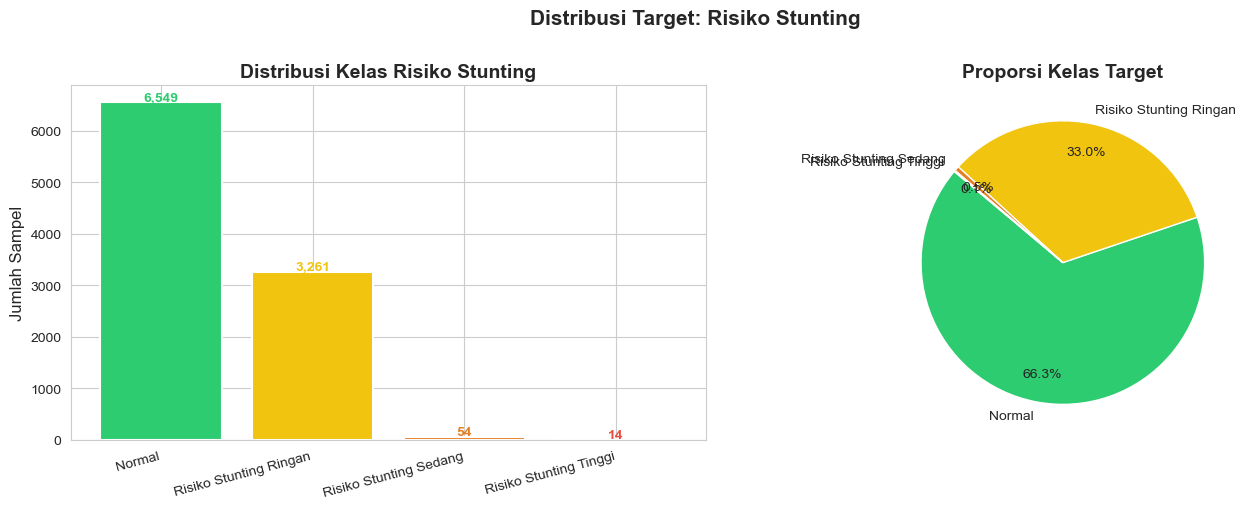

⚠️  CATATAN: Dataset sangat imbalanced!.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dist_ordered = df['stunting_risk'].value_counts().reindex(CLASS_NAMES)

axes[0].bar(CLASS_NAMES, dist_ordered.values, color=CLASS_COLORS, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Kelas Risiko Stunting', fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_xticklabels(CLASS_NAMES, rotation=15, ha='right')
for i, (v, c) in enumerate(zip(dist_ordered.values, CLASS_COLORS)):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold', color=c)

wedges, texts, autotexts = axes[1].pie(
    dist_ordered.values, labels=CLASS_NAMES, colors=CLASS_COLORS,
    autopct='%1.1f%%', startangle=140, pctdistance=0.8
)
for at in autotexts:
    at.set_fontsize(10)
axes[1].set_title('Proporsi Kelas Target', fontweight='bold')

plt.suptitle('Distribusi Target: Risiko Stunting', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('target_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("⚠️  CATATAN: Dataset sangat imbalanced!.")

In [ ]:
df['bmi'] = df['Berat'] / ((df['Tinggi'] / 100) ** 2)

df['jk_enc'] = (df['JK'].str.strip().str.upper() == 'L').astype(int)

naik_map = {'T': 2, 'N': 1}
df['naik_bb_enc'] = df['Naik Berat Badan'].str.strip().map(naik_map).fillna(0).astype(int)

df['cara_ukur_enc'] = (df['Cara Ukur'].str.strip().str.lower() == 'berdiri').astype(int)

df = df.sort_values(['NIK', 'tgl_ukur']).reset_index(drop=True)

delta_usia_bulan  = df.groupby('NIK')['usia_bulan'].diff()
delta_berat       = df.groupby('NIK')['Berat'].diff()
delta_tinggi      = df.groupby('NIK')['Tinggi'].diff()

delta_usia_safe   = delta_usia_bulan.replace(0, np.nan)

df['velocity_berat']  = (delta_berat  / delta_usia_safe)
df['velocity_tinggi'] = (delta_tinggi / delta_usia_safe)

df['velocity_berat']  = df['velocity_berat'].fillna(0)
df['velocity_tinggi'] = df['velocity_tinggi'].fillna(0)

df['velocity_berat']  = df['velocity_berat'].clip(-2, 3)
df['velocity_tinggi'] = df['velocity_tinggi'].clip(-3, 5)

print("✅ Feature Engineering selesai")
print("\nFitur baru yang dibuat:")
new_features = ['bmi', 'jk_enc', 'naik_bb_enc', 'cara_ukur_enc', 'velocity_berat', 'velocity_tinggi']
for f in new_features:
    print(f"   {f:25s} → min={df[f].min():.2f}, max={df[f].max():.2f}, "
          f"mean={df[f].mean():.2f}, null={df[f].isna().sum()}")

✅ Feature Engineering selesai

Fitur baru yang dibuat:
   bmi                       → min=10.41, max=24.10, mean=16.07, null=0
   jk_enc                    → min=0.00, max=1.00, mean=0.52, null=0
   naik_bb_enc               → min=0.00, max=2.00, mean=1.21, null=0
   cara_ukur_enc             → min=0.00, max=1.00, mean=0.67, null=0
   velocity_berat            → min=-2.00, max=3.00, mean=0.26, null=0
   velocity_tinggi           → min=-3.00, max=5.00, mean=0.90, null=0


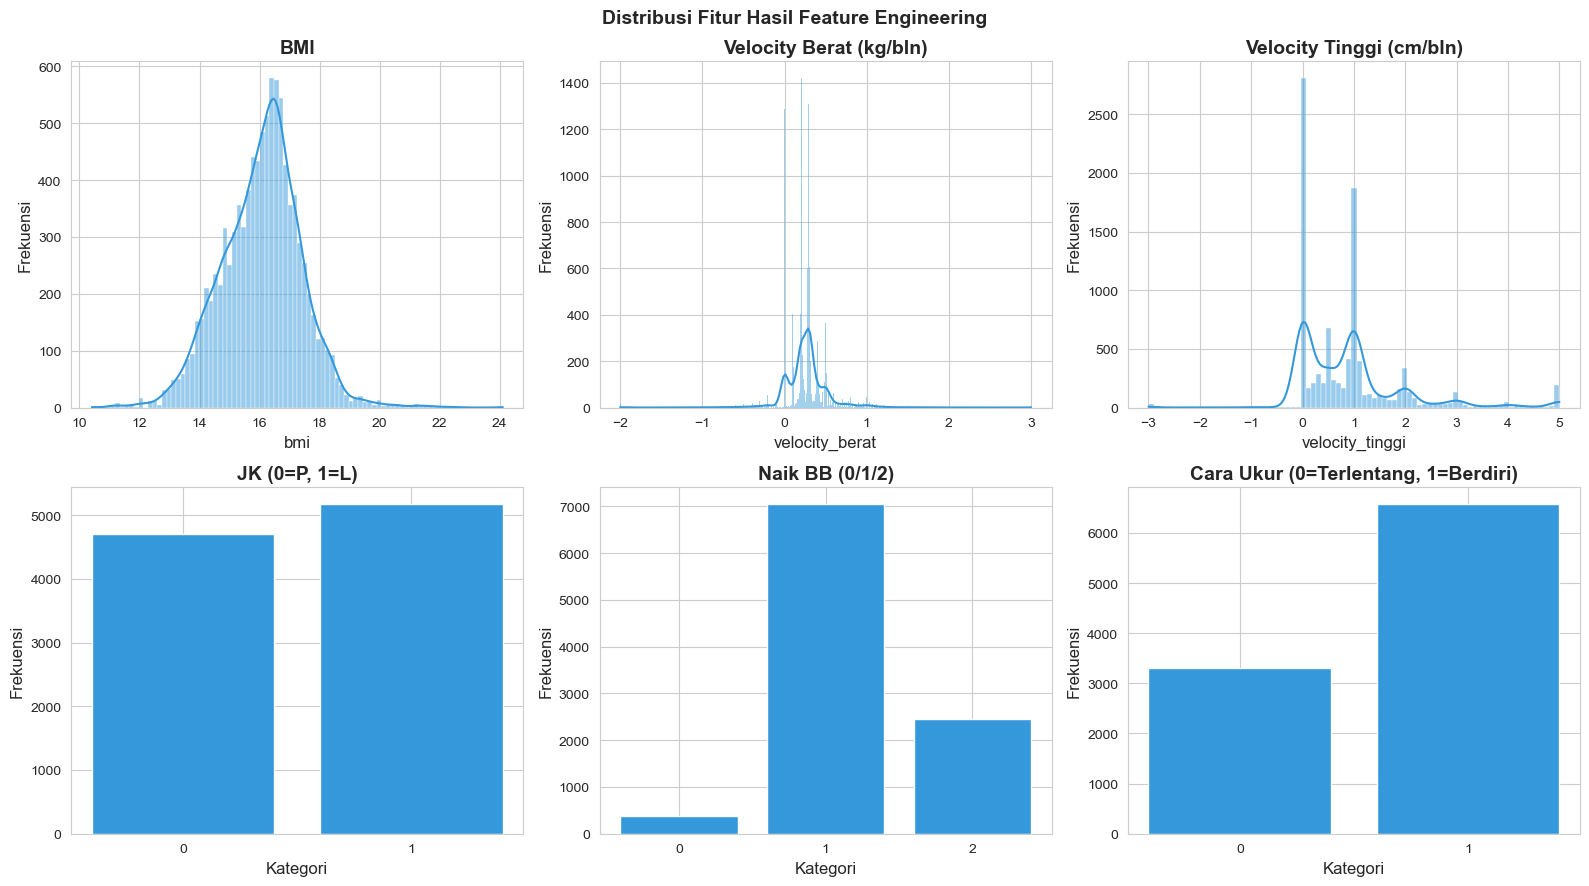

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
feat_to_plot = ['bmi', 'velocity_berat', 'velocity_tinggi', 'jk_enc', 'naik_bb_enc', 'cara_ukur_enc']
titles       = ['BMI', 'Velocity Berat (kg/bln)', 'Velocity Tinggi (cm/bln)',
                'JK (0=P, 1=L)', 'Naik BB (0/1/2)', 'Cara Ukur (0=Terlentang, 1=Berdiri)']

for ax, feat, title in zip(axes.flat, feat_to_plot, titles):
    if df[feat].nunique() <= 5:
        vc = df[feat].value_counts().sort_index()
        ax.bar(vc.index.astype(str), vc.values, color='#3498DB', edgecolor='white')
        ax.set_xlabel('Kategori')
    else:
        sns.histplot(df[feat], ax=ax, kde=True, color='#3498DB', edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Frekuensi')

plt.suptitle('Distribusi Fitur Hasil Feature Engineering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_engineering.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
FEATURE_COLS = [
    'usia_bulan',          # Usia dalam bulan (dari parse teks)
    'jk_enc',              # Jenis kelamin (L=1, P=0)
    'BB Lahir',            # Berat badan lahir (kg)
    'TB Lahir',            # Tinggi badan lahir (cm)
    'Berat',               # Berat badan saat pengukuran (kg)
    'Tinggi',              # Tinggi badan saat pengukuran (cm)
    'LiLA',                # Lingkar lengan atas (cm)
    'ZS BB/U',             # Z-Score Berat Badan per Umur (underweight)
    'ZS BB/TB',            # Z-Score Berat per Tinggi (wasting)
    'bmi',                 # Body Mass Index
    'naik_bb_enc',         # Status kenaikan berat badan
    'cara_ukur_enc',       # Cara pengukuran (berdiri/terlentang)
    'velocity_berat',      # Kecepatan pertumbuhan berat (kg/bulan)
    'velocity_tinggi',     # Kecepatan pertumbuhan tinggi (cm/bulan)
]
TARGET_COL = 'stunting_risk'

df_model = df[FEATURE_COLS + [TARGET_COL]].copy()
df_model = df_model.dropna(subset=FEATURE_COLS + [TARGET_COL])

print("=" * 60)
print(f"Dataset siap ML: {df_model.shape}")
print(f"  Fitur  : {len(FEATURE_COLS)} kolom")
print(f"  Target : {TARGET_COL}")
print("=" * 60)
print("\nFitur yang digunakan:")
for i, f in enumerate(FEATURE_COLS, 1):
    print(f"  {i:2d}. {f}")
print("\nDistribusi target:")
print(df_model[TARGET_COL].value_counts().reindex(CLASS_NAMES).to_string())

Dataset siap ML: (9878, 15)
  Fitur  : 14 kolom
  Target : stunting_risk

Fitur yang digunakan:
   1. usia_bulan
   2. jk_enc
   3. BB Lahir
   4. TB Lahir
   5. Berat
   6. Tinggi
   7. LiLA
   8. ZS BB/U
   9. ZS BB/TB
  10. bmi
  11. naik_bb_enc
  12. cara_ukur_enc
  13. velocity_berat
  14. velocity_tinggi

Distribusi target:
stunting_risk
Normal                    6549
Risiko Stunting Ringan    3261
Risiko Stunting Sedang      54
Risiko Stunting Tinggi      14


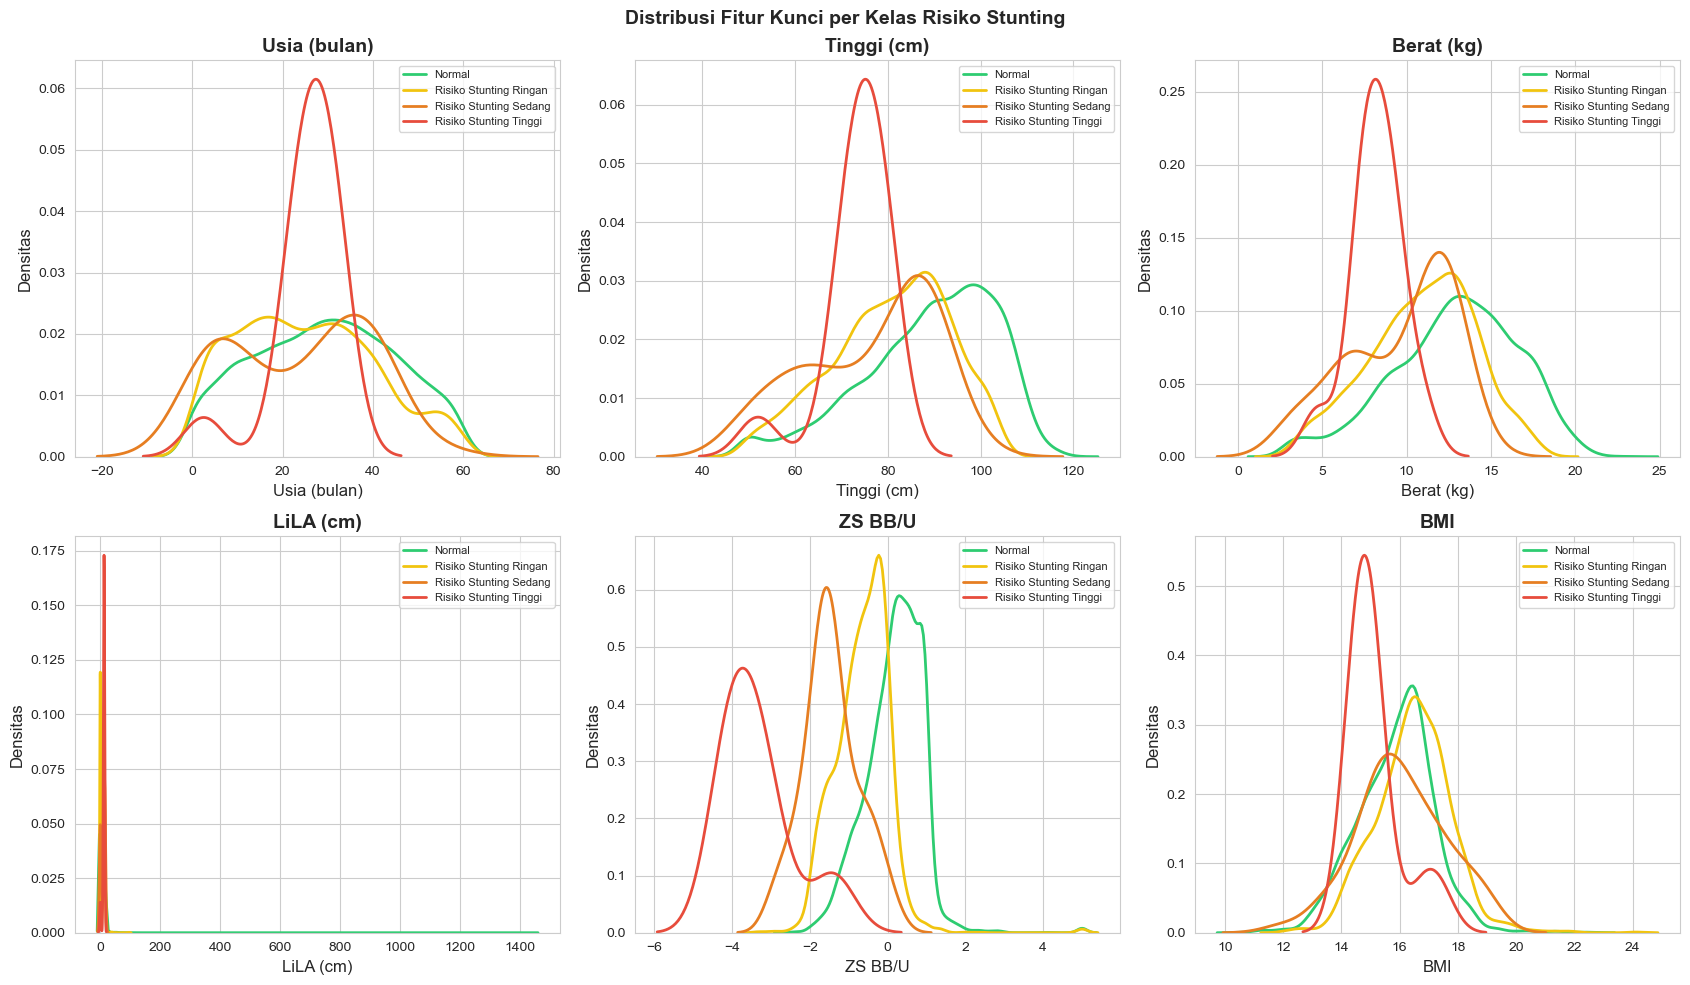

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
key_features = ['usia_bulan', 'Tinggi', 'Berat', 'LiLA', 'ZS BB/U', 'bmi']
key_labels   = ['Usia (bulan)', 'Tinggi (cm)', 'Berat (kg)',
                'LiLA (cm)', 'ZS BB/U', 'BMI']

for ax, feat, label in zip(axes.flat, key_features, key_labels):
    for cls, color in zip(CLASS_NAMES, CLASS_COLORS):
        subset = df_model[df_model[TARGET_COL] == cls][feat].dropna()
        if len(subset) > 5:
            sns.kdeplot(subset, ax=ax, label=cls, color=color, linewidth=2)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Densitas')
    ax.legend(fontsize=8)

plt.suptitle('Distribusi Fitur Kunci per Kelas Risiko Stunting',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

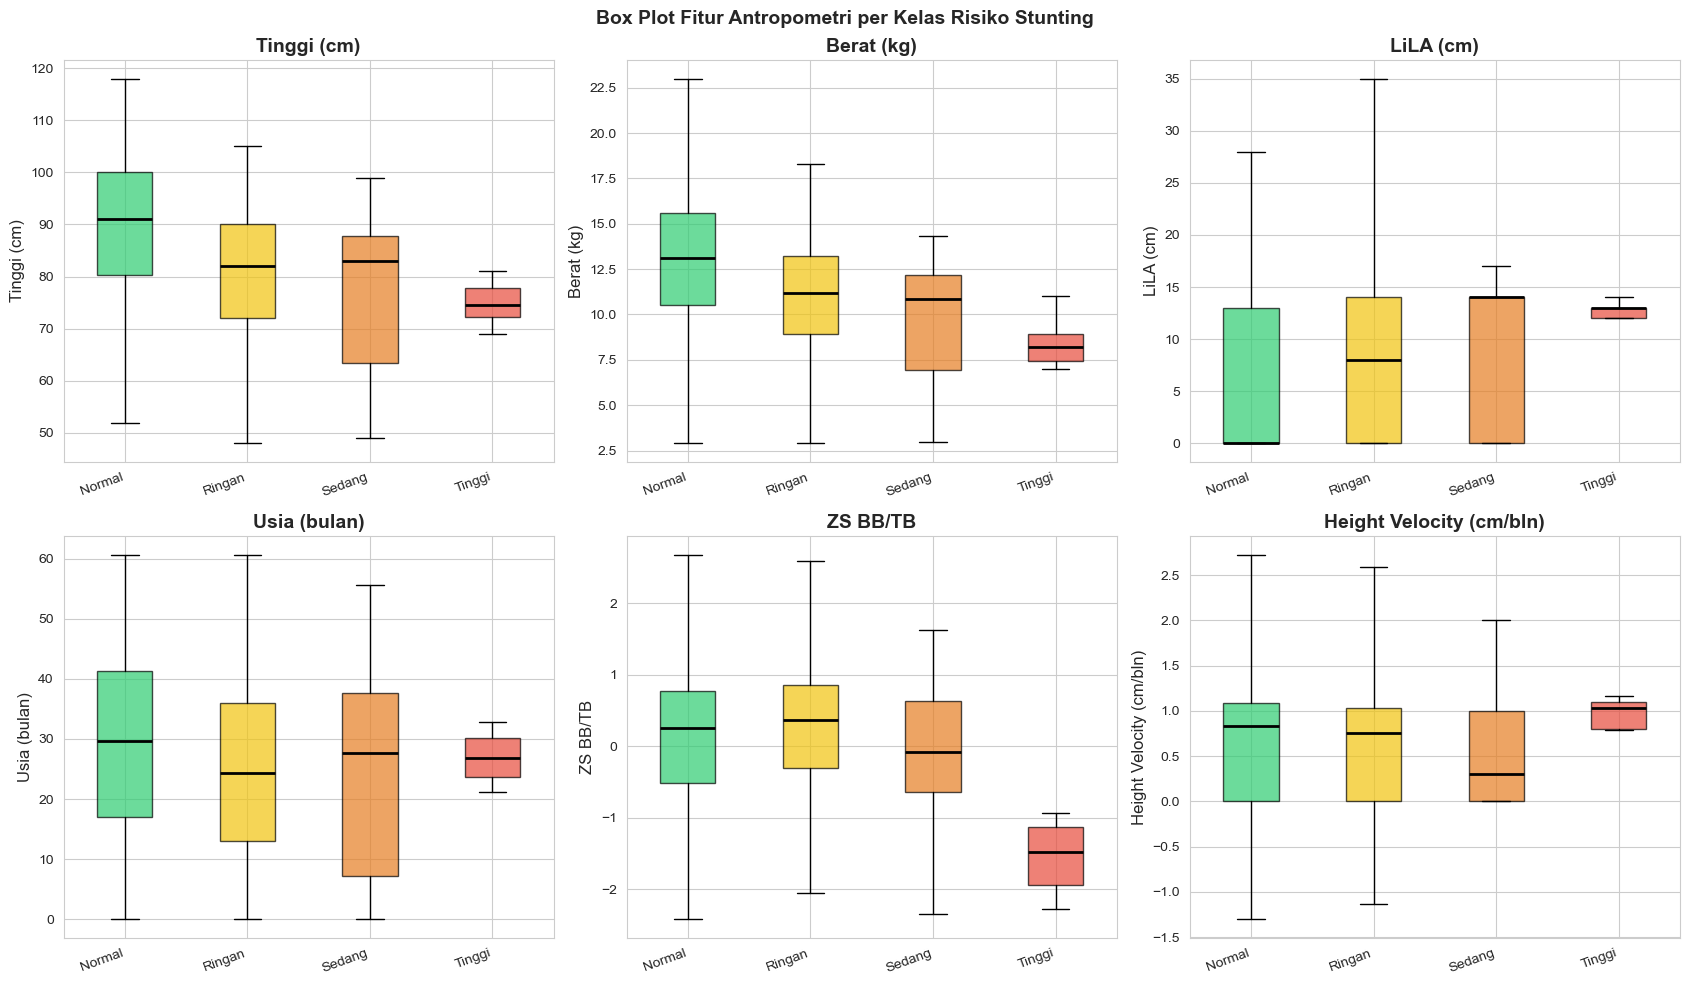

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
box_features = ['Tinggi', 'Berat', 'LiLA', 'usia_bulan', 'ZS BB/TB', 'velocity_tinggi']
box_labels   = ['Tinggi (cm)', 'Berat (kg)', 'LiLA (cm)',
                'Usia (bulan)', 'ZS BB/TB', 'Height Velocity (cm/bln)']

for ax, feat, label in zip(axes.flat, box_features, box_labels):
    data_by_class = [
        df_model[df_model[TARGET_COL] == cls][feat].dropna().values
        for cls in CLASS_NAMES
    ]
    bp = ax.boxplot(data_by_class, patch_artist=True, showfliers=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], CLASS_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(label, fontweight='bold')
    ax.set_xticklabels(
        ['Normal', 'Ringan', 'Sedang', 'Tinggi'],
        rotation=20, ha='right'
    )
    ax.set_ylabel(label)

plt.suptitle('Box Plot Fitur Antropometri per Kelas Risiko Stunting',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_boxplots.png', bbox_inches='tight', dpi=150)
plt.show()

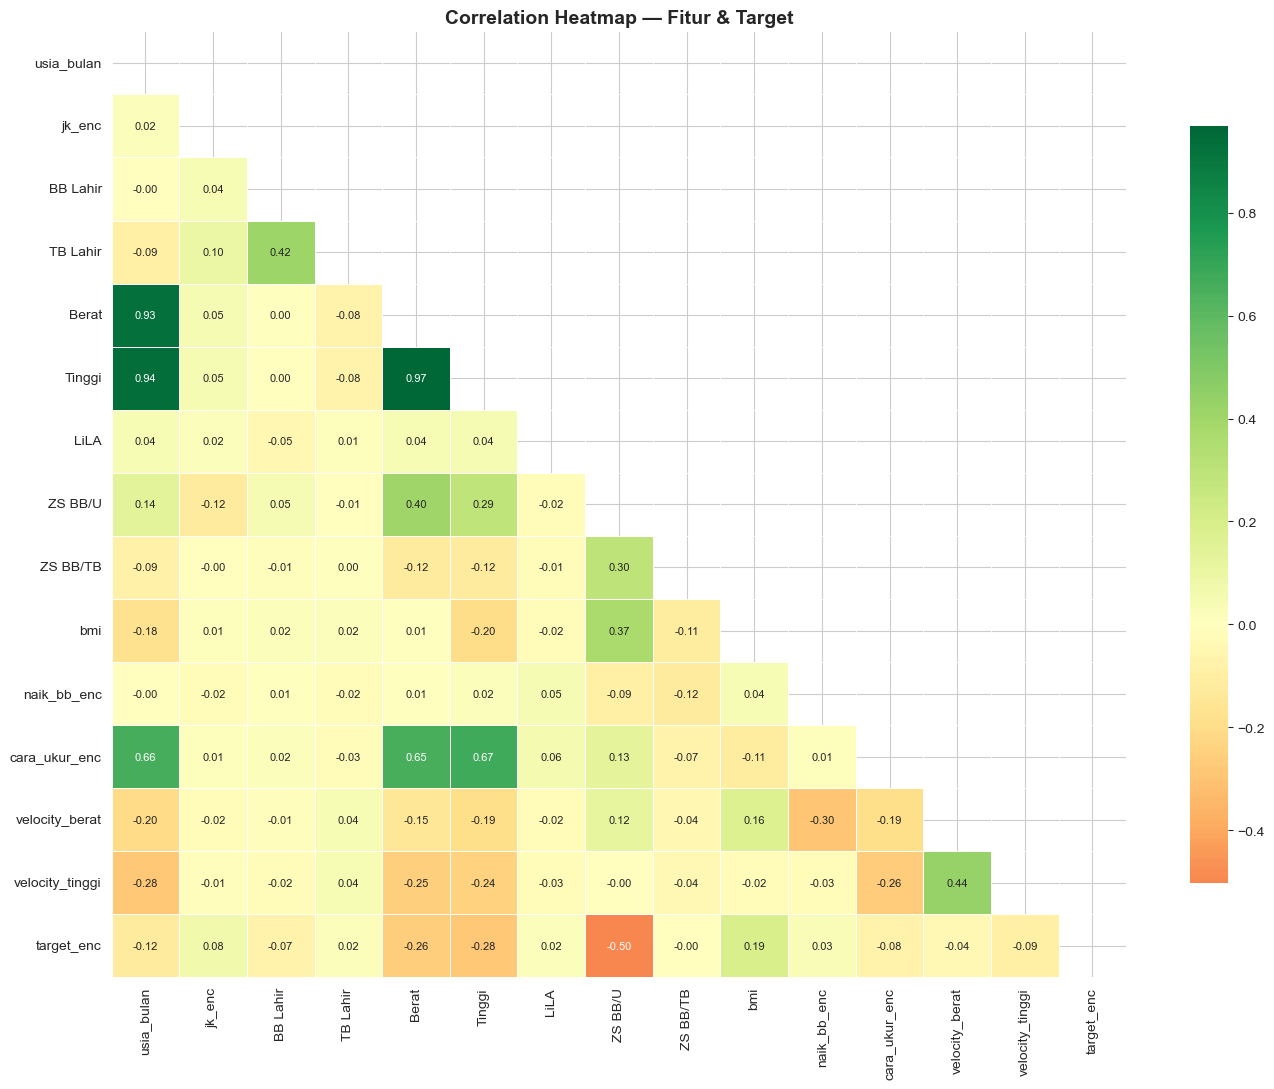

In [ ]:
le_temp = LabelEncoder()
df_corr = df_model.copy()
df_corr['target_enc'] = le_temp.fit_transform(df_corr[TARGET_COL])
corr_matrix = df_corr[FEATURE_COLS + ['target_enc']].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8},
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Heatmap — Fitur & Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

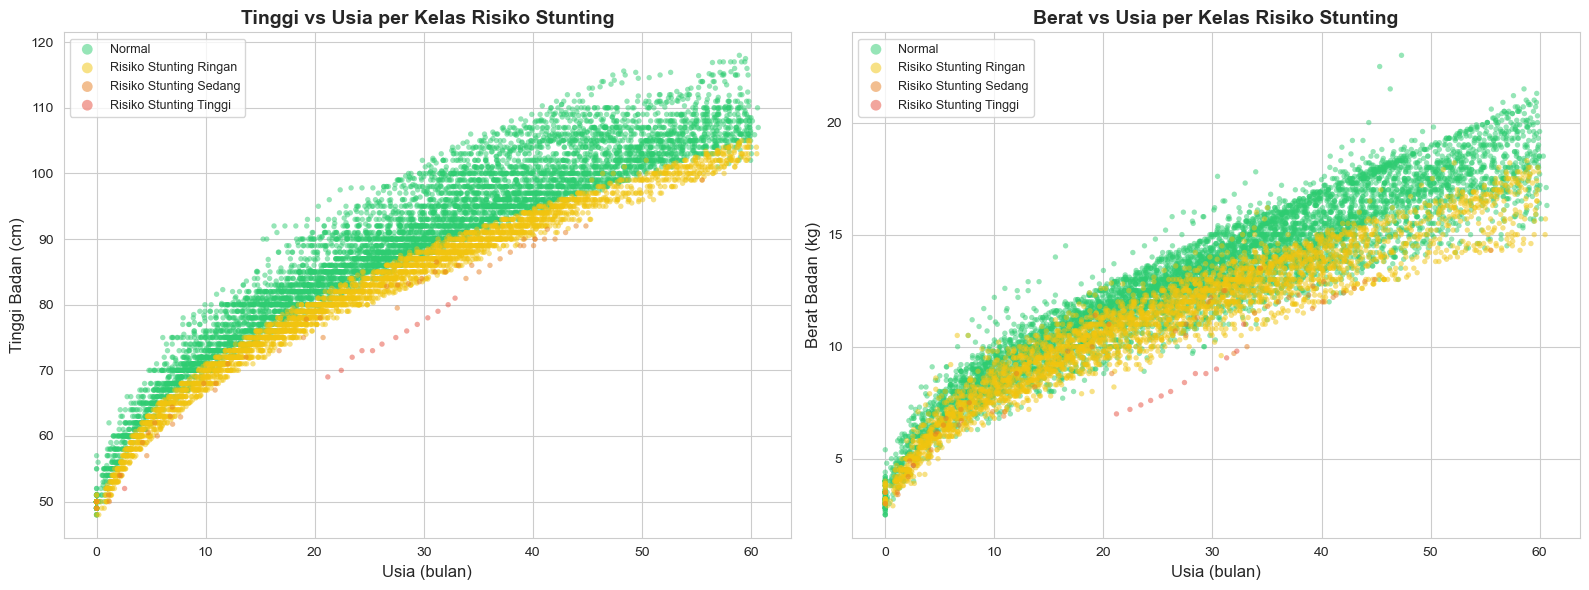

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for cls, color in zip(CLASS_NAMES, CLASS_COLORS):
    subset = df_model[df_model[TARGET_COL] == cls]
    axes[0].scatter(subset['usia_bulan'], subset['Tinggi'],
                    c=color, label=cls, alpha=0.5, s=15, edgecolors='none')

axes[0].set_xlabel('Usia (bulan)')
axes[0].set_ylabel('Tinggi Badan (cm)')
axes[0].set_title('Tinggi vs Usia per Kelas Risiko Stunting', fontweight='bold')
axes[0].legend(markerscale=2, fontsize=9)

for cls, color in zip(CLASS_NAMES, CLASS_COLORS):
    subset = df_model[df_model[TARGET_COL] == cls]
    axes[1].scatter(subset['usia_bulan'], subset['Berat'],
                    c=color, label=cls, alpha=0.5, s=15, edgecolors='none')

axes[1].set_xlabel('Usia (bulan)')
axes[1].set_ylabel('Berat Badan (kg)')
axes[1].set_title('Berat vs Usia per Kelas Risiko Stunting', fontweight='bold')
axes[1].legend(markerscale=2, fontsize=9)

plt.tight_layout()
plt.savefig('eda_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

In [22]:
X = df_model[FEATURE_COLS].values
y = df_model[TARGET_COL].values

# Stratified split 80:20 → menjaga proporsi kelas
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("=" * 55)
print("PEMBAGIAN DATA TRAIN / TEST")
print("=" * 55)
print(f"  Total sampel  : {len(X):,}")
print(f"  Training set  : {len(X_train_raw):,}  (80%)")
print(f"  Test set      : {len(X_test_raw):,}   (20%)")

print("\nDistribusi kelas — Training Set:")
for cls in CLASS_NAMES:
    n   = (y_train_raw == cls).sum()
    pct = n / len(y_train_raw) * 100
    print(f"  {cls:<32}: {n:4d} ({pct:.1f}%)")

print("\nDistribusi kelas — Test Set:")
for cls in CLASS_NAMES:
    n   = (y_test_raw == cls).sum()
    pct = n / len(y_test_raw) * 100
    print(f"  {cls:<32}: {n:4d} ({pct:.1f}%)")

PEMBAGIAN DATA TRAIN / TEST
  Total sampel  : 9,878
  Training set  : 7,902  (80%)
  Test set      : 1,976   (20%)

Distribusi kelas — Training Set:
  Normal                          : 5239 (66.3%)
  Risiko Stunting Ringan          : 2609 (33.0%)
  Risiko Stunting Sedang          :   43 (0.5%)
  Risiko Stunting Tinggi          :   11 (0.1%)

Distribusi kelas — Test Set:
  Normal                          : 1310 (66.3%)
  Risiko Stunting Ringan          :  652 (33.0%)
  Risiko Stunting Sedang          :   11 (0.6%)
  Risiko Stunting Tinggi          :    3 (0.2%)


In [ ]:
le_target = LabelEncoder()
le_target.classes_ = np.array(CLASS_NAMES)   # pastikan urutan: 0=Normal dst.
y_train_enc = le_target.transform(y_train_raw)
y_test_enc  = le_target.transform(y_test_raw)

print("Label Encoding (Target):")
for i, cls in enumerate(le_target.classes_):
    print(f"  {i} → {cls}")

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw)   # fit HANYA pada train
X_test_sc  = scaler.transform(X_test_raw)         # transform test dengan scaler train

print(f"\n✅ StandardScaler diterapkan pada {X_train_sc.shape[1]} fitur")
print(f"   Rata-rata fitur (setelah scaling) ≈ {X_train_sc.mean():.4f}")
print(f"   Std fitur (setelah scaling) ≈ {X_train_sc.std():.4f}")

Label Encoding (Target):
  0 → Normal
  1 → Risiko Stunting Ringan
  2 → Risiko Stunting Sedang
  3 → Risiko Stunting Tinggi

✅ StandardScaler diterapkan pada 14 fitur
   Rata-rata fitur (setelah scaling) ≈ -0.0000
   Std fitur (setelah scaling) ≈ 1.0000


In [ ]:
mi_scores = mutual_info_classif(
    X_train_sc, y_train_enc, random_state=RANDOM_STATE, n_neighbors=5
)
mi_df = pd.DataFrame({
    'Fitur'     : FEATURE_COLS,
    'MI Score'  : mi_scores
}).sort_values('MI Score', ascending=False)

print("=" * 55)
print("MUTUAL INFORMATION SCORE (Feature vs Target)")
print("=" * 55)
print(mi_df.to_string(index=False))

MUTUAL INFORMATION SCORE (Feature vs Target)
          Fitur  MI Score
        ZS BB/U  0.166501
         Tinggi  0.078226
          Berat  0.054730
            bmi  0.049211
       BB Lahir  0.025956
       ZS BB/TB  0.024679
           LiLA  0.024054
 velocity_berat  0.018940
velocity_tinggi  0.018129
     usia_bulan  0.017134
       TB Lahir  0.012568
         jk_enc  0.008199
  cara_ukur_enc  0.004115
    naik_bb_enc  0.001762


RANDOM FOREST FEATURE IMPORTANCE
          Fitur  Importance
        ZS BB/U    0.294926
       ZS BB/TB    0.107261
         Tinggi    0.090461
            bmi    0.088246
       BB Lahir    0.082189
     usia_bulan    0.077429
          Berat    0.076671
           LiLA    0.053371
 velocity_berat    0.034848
velocity_tinggi    0.034281
    naik_bb_enc    0.020465
       TB Lahir    0.018127
         jk_enc    0.015432
  cara_ukur_enc    0.006292


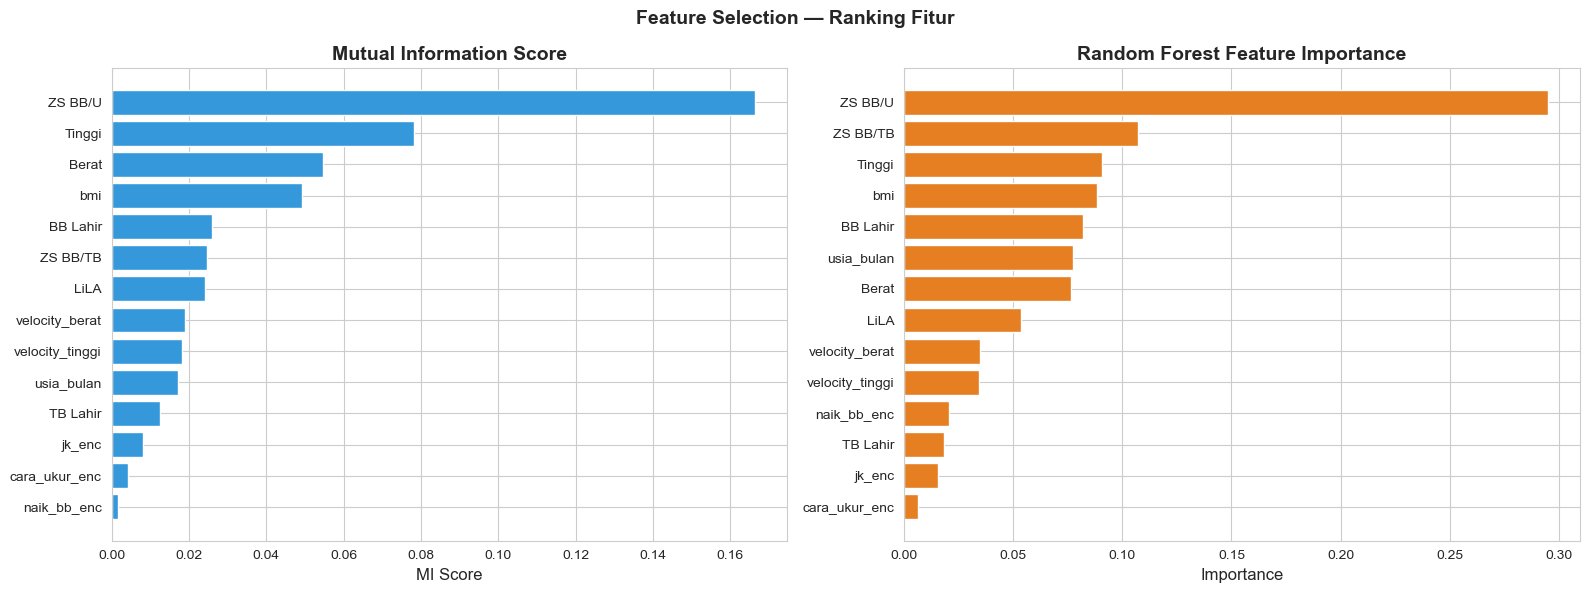

In [ ]:
rf_quick = RandomForestClassifier(
    n_estimators=100, random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1
)
rf_quick.fit(X_train_sc, y_train_enc)

importance_df = pd.DataFrame({
    'Fitur'      : FEATURE_COLS,
    'Importance' : rf_quick.feature_importances_
}).sort_values('Importance', ascending=False)

print("=" * 55)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 55)
print(importance_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(mi_df['Fitur'][::-1], mi_df['MI Score'][::-1], color='#3498DB', edgecolor='white')
axes[0].set_title('Mutual Information Score', fontweight='bold')
axes[0].set_xlabel('MI Score')

axes[1].barh(importance_df['Fitur'][::-1], importance_df['Importance'][::-1],
             color='#E67E22', edgecolor='white')
axes[1].set_title('Random Forest Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.suptitle('Feature Selection — Ranking Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_selection.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
MI_THRESHOLD   = 0.005
selected_feats = mi_df[mi_df['MI Score'] >= MI_THRESHOLD]['Fitur'].tolist()

if len(selected_feats) < 5:
    print(f"⚠️  Hanya {len(selected_feats)} fitur lolos threshold. "
          f"Gunakan top-10 berdasarkan MI score.")
    selected_feats = mi_df.head(min(10, len(mi_df)))['Fitur'].tolist()

selected_idx   = [FEATURE_COLS.index(f) for f in selected_feats]
X_train_sel    = X_train_sc[:, selected_idx]
X_test_sel     = X_test_sc[:, selected_idx]

print(f"Fitur SEBELUM seleksi : {len(FEATURE_COLS)}")
print(f"Fitur SETELAH seleksi : {len(selected_feats)}")
print("\nFitur terpilih:")
for i, f in enumerate(selected_feats, 1):
    mi = mi_df[mi_df['Fitur'] == f]['MI Score'].values[0]
    rf_imp = importance_df[importance_df['Fitur'] == f]['Importance'].values[0]
    print(f"  {i:2d}. {f:<30} MI={mi:.4f} | RF-Imp={rf_imp:.4f}")

Fitur SEBELUM seleksi : 14
Fitur SETELAH seleksi : 12

Fitur terpilih:
   1. ZS BB/U                        MI=0.1665 | RF-Imp=0.2949
   2. Tinggi                         MI=0.0782 | RF-Imp=0.0905
   3. Berat                          MI=0.0547 | RF-Imp=0.0767
   4. bmi                            MI=0.0492 | RF-Imp=0.0882
   5. BB Lahir                       MI=0.0260 | RF-Imp=0.0822
   6. ZS BB/TB                       MI=0.0247 | RF-Imp=0.1073
   7. LiLA                           MI=0.0241 | RF-Imp=0.0534
   8. velocity_berat                 MI=0.0189 | RF-Imp=0.0348
   9. velocity_tinggi                MI=0.0181 | RF-Imp=0.0343
  10. usia_bulan                     MI=0.0171 | RF-Imp=0.0774
  11. TB Lahir                       MI=0.0126 | RF-Imp=0.0181
  12. jk_enc                         MI=0.0082 | RF-Imp=0.0154


In [ ]:
counter_before = Counter(y_train_enc)
print("Distribusi SEBELUM SMOTE:")
for enc_cls, cls_name in enumerate(le_target.classes_):
    print(f"  [{enc_cls}] {cls_name:<32}: {counter_before[enc_cls]:,}")

min_cls_count = min(counter_before.values())
k_n = min(5, max(1, min_cls_count - 1))
print(f"\nk_neighbors dipilih: {k_n} (dari min class={min_cls_count})")

majority_count = max(counter_before.values())
target_n       = max(min_cls_count + 1, int(majority_count * 0.10))
sampling_strategy = {
    enc: target_n
    for enc, count in counter_before.items()
    if count < target_n
}

print(f"Target sampel per kelas minority: {target_n:,}")
if not sampling_strategy:
    print("Semua kelas sudah cukup — SMOTE tidak diperlukan.")
    X_train_res, y_train_res = X_train_sel, y_train_enc
else:
    print(f"Kelas yang akan di-oversample: {sampling_strategy}")
    smote = SMOTE(
        sampling_strategy = sampling_strategy,
        k_neighbors       = k_n,
        random_state      = RANDOM_STATE
    )
    X_train_res, y_train_res = smote.fit_resample(X_train_sel, y_train_enc)

counter_after = Counter(y_train_res)
print("\nDistribusi SETELAH SMOTE:")
for enc_cls, cls_name in enumerate(le_target.classes_):
    n_before = counter_before[enc_cls]
    n_after  = counter_after[enc_cls]
    synth    = n_after - n_before
    tag      = f'(+{synth:,} sintetis)' if synth > 0 else '(tidak berubah)'
    print(f"  [{enc_cls}] {cls_name:<32}: {n_after:,}  {tag}")

print(f"\n  Total training samples: {len(X_train_res):,}")

Distribusi SEBELUM SMOTE:
  [0] Normal                          : 5,239
  [1] Risiko Stunting Ringan          : 2,609
  [2] Risiko Stunting Sedang          : 43
  [3] Risiko Stunting Tinggi          : 11

k_neighbors dipilih: 5 (dari min class=11)
Target sampel per kelas minority: 523
Kelas yang akan di-oversample: {np.int64(2): 523, np.int64(3): 523}

Distribusi SETELAH SMOTE:
  [0] Normal                          : 5,239  (tidak berubah)
  [1] Risiko Stunting Ringan          : 2,609  (tidak berubah)
  [2] Risiko Stunting Sedang          : 523  (+480 sintetis)
  [3] Risiko Stunting Tinggi          : 523  (+512 sintetis)

  Total training samples: 8,894


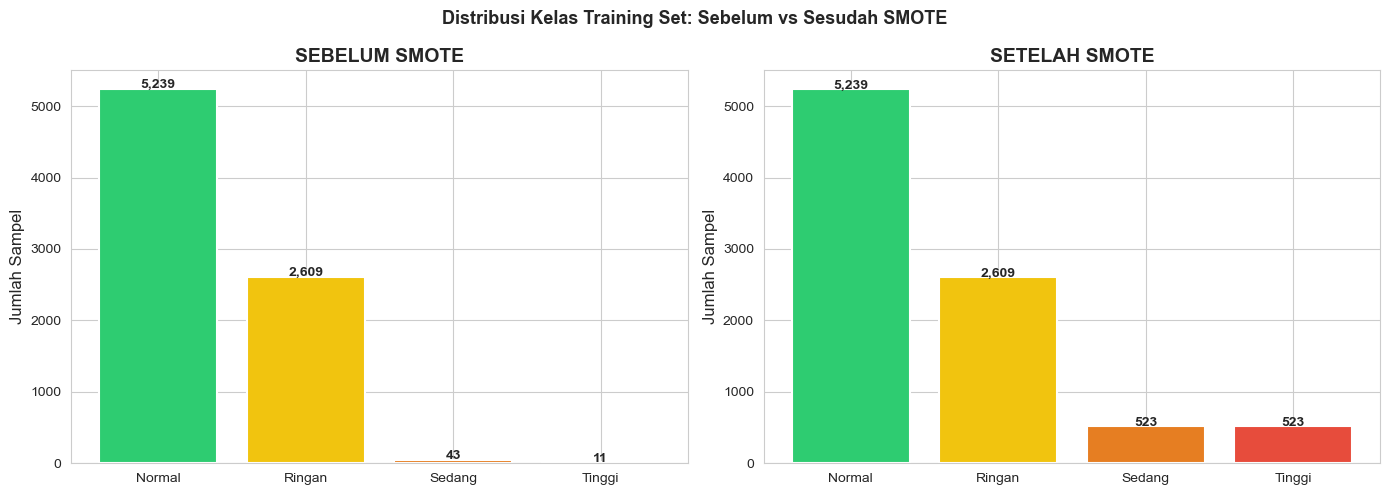

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels_short = ['Normal', 'Ringan', 'Sedang', 'Tinggi']

vals_before = [counter_before[i] for i in range(len(CLASS_NAMES))]
vals_after  = [counter_after[i]  for i in range(len(CLASS_NAMES))]

axes[0].bar(labels_short, vals_before, color=CLASS_COLORS, edgecolor='white', linewidth=1.5)
axes[0].set_title('SEBELUM SMOTE', fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
for i, v in enumerate(vals_before):
    axes[0].text(i, v + 10, f'{v:,}', ha='center', fontsize=10, fontweight='bold')

axes[1].bar(labels_short, vals_after, color=CLASS_COLORS, edgecolor='white', linewidth=1.5)
axes[1].set_title('SETELAH SMOTE', fontweight='bold')
axes[1].set_ylabel('Jumlah Sampel')
for i, v in enumerate(vals_after):
    axes[1].text(i, v + 5, f'{v:,}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Distribusi Kelas Training Set: Sebelum vs Sesudah SMOTE',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('smote_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
def evaluate_model_cv(model, X, y, cv=5, scoring='f1_macro'):
    """Cross-validation evaluation helper."""
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X, y, cv=skf, scoring=scoring, n_jobs=-1)
    return scores.mean(), scores.std()

baselines = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', max_depth=8, random_state=RANDOM_STATE
    )
}

print("=" * 65)
print("BASELINE MODEL — Cross-Validation (5-fold, Macro F1)")
print("=" * 65)
baseline_results = {}

for name, model in baselines.items():
    mean_f1, std_f1 = evaluate_model_cv(model, X_train_res, y_train_res)
    baseline_results[name] = {'mean_f1': mean_f1, 'std_f1': std_f1}
    print(f"  {name:<25}: F1 = {mean_f1:.4f} (±{std_f1:.4f})")

print("\n(Nilai F1 Macro yang tinggi menunjukkan model belajar semua kelas dengan baik)")

BASELINE MODEL — Cross-Validation (5-fold, Macro F1)
  Logistic Regression      : F1 = 0.8821 (±0.0029)
  Decision Tree            : F1 = 0.8830 (±0.0152)

(Nilai F1 Macro yang tinggi menunjukkan model belajar semua kelas dengan baik)


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

MODELS = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05,
        max_depth=5, random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, learning_rate=0.05,
        max_depth=5, use_label_encoder=False,
        eval_metric='mlogloss', random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200, learning_rate=0.05,
        num_leaves=31, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    ),
}

print("=" * 65)
print("MODEL COMPARISON — 5-Fold Stratified Cross-Validation")
print("Metric: Macro F1 Score (semua kelas dihitung sama bobotnya)")
print("=" * 65)

comparison_results = {}
for name, model in MODELS.items():
    mean_f1, std_f1 = evaluate_model_cv(model, X_train_res, y_train_res)
    comparison_results[name] = {
        'mean_f1': mean_f1,
        'std_f1' : std_f1,
        'model'  : model
    }
    bar = '█' * int(mean_f1 * 30)
    print(f"  {name:<22}: F1 = {mean_f1:.4f} (±{std_f1:.4f})  {bar}")

best_model_name = max(comparison_results, key=lambda k: comparison_results[k]['mean_f1'])
print(f"\n🏆 Model Terbaik: {best_model_name}  "
      f"(F1 = {comparison_results[best_model_name]['mean_f1']:.4f})")

MODEL COMPARISON — 5-Fold Stratified Cross-Validation
Metric: Macro F1 Score (semua kelas dihitung sama bobotnya)
  Random Forest         : F1 = 0.9617 (±0.0057)  ████████████████████████████
  Extra Trees           : F1 = 0.9605 (±0.0056)  ████████████████████████████
  Gradient Boosting     : F1 = 0.9713 (±0.0054)  █████████████████████████████
  XGBoost               : F1 = 0.9665 (±0.0028)  ████████████████████████████
  LightGBM              : F1 = 0.9778 (±0.0031)  █████████████████████████████

🏆 Model Terbaik: LightGBM  (F1 = 0.9778)


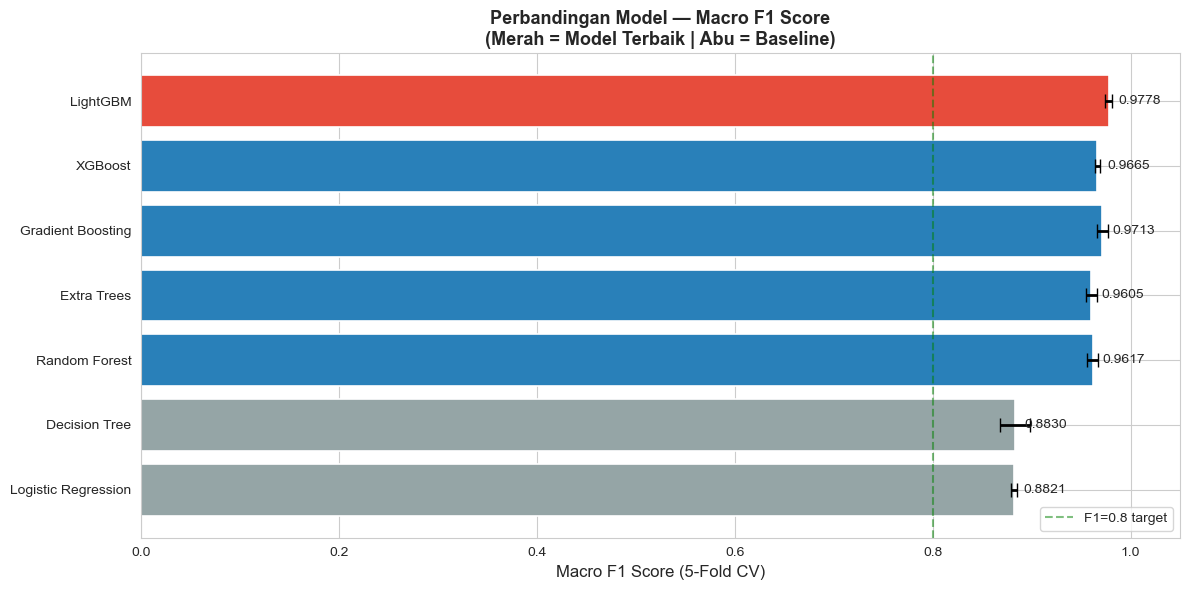

In [ ]:
all_names  = list(baseline_results.keys()) + list(comparison_results.keys())
all_means  = [baseline_results[k]['mean_f1']     for k in baseline_results] +              [comparison_results[k]['mean_f1']    for k in comparison_results]
all_stds   = [baseline_results[k]['std_f1']      for k in baseline_results] +              [comparison_results[k]['std_f1']     for k in comparison_results]

colors = ['#95A5A6'] * len(baseline_results) + ['#2980B9'] * len(comparison_results)
best_idx = all_names.index(best_model_name)
colors[best_idx] = '#E74C3C'

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(all_names, all_means, xerr=all_stds, color=colors,
               edgecolor='white', linewidth=1.2, capsize=5, error_kw={'linewidth': 2})
ax.set_xlabel('Macro F1 Score (5-Fold CV)', fontsize=12)
ax.set_title('Perbandingan Model — Macro F1 Score\n(Merah = Model Terbaik | Abu = Baseline)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.05)
for bar, v in zip(bars, all_means):
    ax.text(v + 0.01, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=10)
ax.axvline(x=0.8, color='green', linestyle='--', alpha=0.5, label='F1=0.8 target')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
print("Melatih semua model pada full training set...")
trained_models = {}
for name, info in comparison_results.items():
    model = info['model']
    model.fit(X_train_res, y_train_res)
    trained_models[name] = model
    print(f"  ✅ {name}")

print("\n" + "=" * 65)
print("INITIAL EVALUATION — TEST SET")
print("=" * 65)

init_metrics = {}
for name, model in trained_models.items():
    y_pred = model.predict(X_test_sel)
    acc    = accuracy_score(y_test_enc, y_pred)
    f1_mac = f1_score(y_test_enc, y_pred, average='macro',    zero_division=0)
    f1_wt  = f1_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    bal_acc= balanced_accuracy_score(y_test_enc, y_pred)
    init_metrics[name] = {
        'Accuracy': acc, 'Balanced Acc': bal_acc,
        'F1 Macro': f1_mac, 'F1 Weighted': f1_wt
    }
    print(f"  {name:<22}| Acc={acc:.4f} | BalAcc={bal_acc:.4f} | "
          f"F1_Mac={f1_mac:.4f} | F1_Wt={f1_wt:.4f}")

init_df = pd.DataFrame(init_metrics).T.round(4)
print("\n")
print(init_df.to_string())

Melatih semua model pada full training set...
  ✅ Random Forest
  ✅ Extra Trees
  ✅ Gradient Boosting
  ✅ XGBoost
  ✅ LightGBM

INITIAL EVALUATION — TEST SET
  Random Forest         | Acc=0.9595 | BalAcc=0.8420 | F1_Mac=0.8839 | F1_Wt=0.9590
  Extra Trees           | Acc=0.9534 | BalAcc=0.8372 | F1_Mac=0.8712 | F1_Wt=0.9528
  Gradient Boosting     | Acc=0.9767 | BalAcc=0.8523 | F1_Mac=0.8846 | F1_Wt=0.9763
  XGBoost               | Acc=0.9742 | BalAcc=0.8506 | F1_Mac=0.8832 | F1_Wt=0.9737
  LightGBM              | Acc=0.9752 | BalAcc=0.8531 | F1_Mac=0.8757 | F1_Wt=0.9749


                   Accuracy  Balanced Acc  F1 Macro  F1 Weighted
Random Forest        0.9595        0.8420    0.8839       0.9590
Extra Trees          0.9534        0.8372    0.8712       0.9528
Gradient Boosting    0.9767        0.8523    0.8846       0.9763
XGBoost              0.9742        0.8506    0.8832       0.9737
LightGBM             0.9752        0.8531    0.8757       0.9749



Classification Report — LightGBM (Initial):
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.98      1310
      Ringan       0.95      0.98      0.96       652
      Sedang       0.71      0.45      0.56        11
      Tinggi       1.00      1.00      1.00         3

    accuracy                           0.98      1976
   macro avg       0.91      0.85      0.88      1976
weighted avg       0.98      0.98      0.97      1976



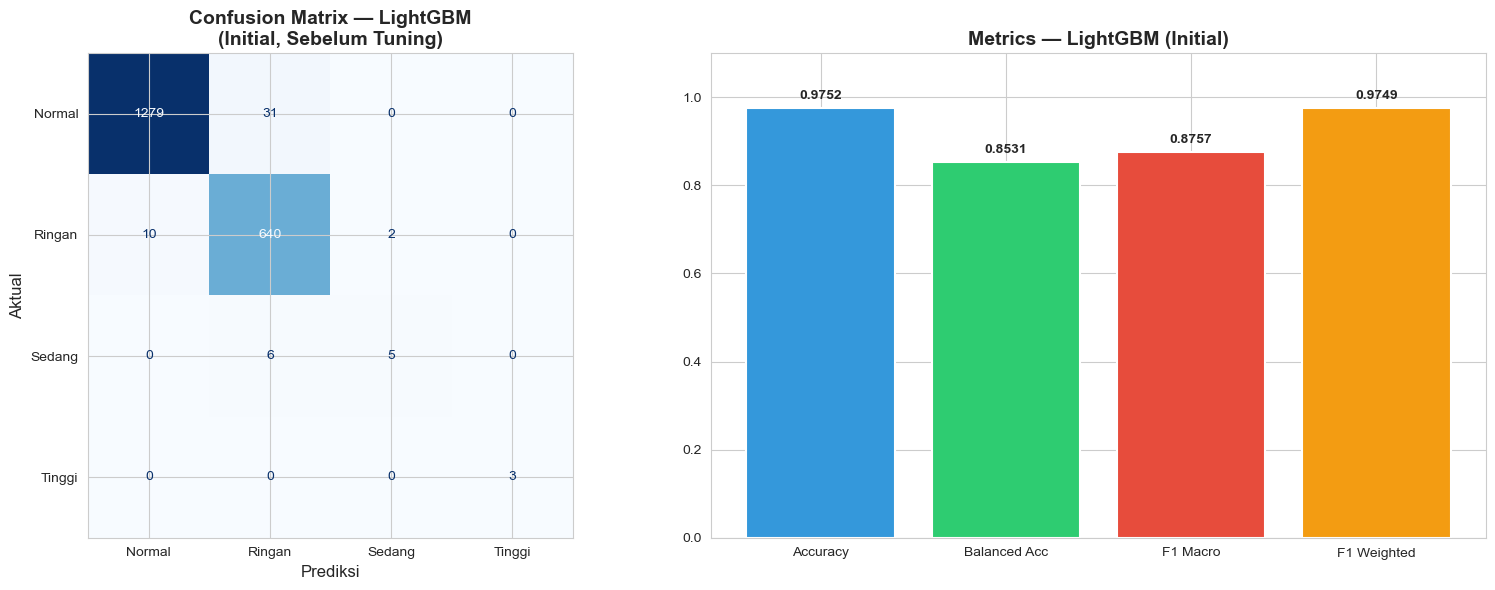

In [ ]:
best_model_init = trained_models[best_model_name]
y_pred_init     = best_model_init.predict(X_test_sel)
cm = confusion_matrix(y_test_enc, y_pred_init)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Normal', 'Ringan', 'Sedang', 'Tinggi']
)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix — {best_model_name}\n(Initial, Sebelum Tuning)',
                  fontweight='bold')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

print(f"\nClassification Report — {best_model_name} (Initial):")
print(classification_report(
    y_test_enc, y_pred_init,
    target_names=['Normal', 'Ringan', 'Sedang', 'Tinggi'],
    zero_division=0
))

metrics_names = ['Accuracy', 'Balanced Acc', 'F1 Macro', 'F1 Weighted']
best_vals = [init_metrics[best_model_name][m] for m in metrics_names]
axes[1].bar(metrics_names, best_vals, color=['#3498DB','#2ECC71','#E74C3C','#F39C12'],
            edgecolor='white', linewidth=1.5)
axes[1].set_ylim(0, 1.1)
axes[1].set_title(f'Metrics — {best_model_name} (Initial)', fontweight='bold')
for i, v in enumerate(best_vals):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('initial_evaluation.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score

print(f"🔬 Tuning model: {best_model_name}")
print("   Jumlah trials: 60")
print("   CV: StratifiedKFold(5), scoring=F1 Macro")
print("   Estimasi waktu: 2-5 menit...\n")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def objective_lgbm(trial):
    params = {
        'n_estimators'     : trial.suggest_int   ('n_estimators',    100, 800),
        'learning_rate'    : trial.suggest_float  ('learning_rate',   0.01, 0.3,   log=True),
        'num_leaves'       : trial.suggest_int   ('num_leaves',      16, 127),
        'max_depth'        : trial.suggest_int   ('max_depth',       3, 10),
        'min_child_samples': trial.suggest_int   ('min_child_samples', 5, 50),
        'subsample'        : trial.suggest_float  ('subsample',       0.6, 1.0),
        'colsample_bytree' : trial.suggest_float  ('colsample_bytree',0.6, 1.0),
        'reg_alpha'        : trial.suggest_float  ('reg_alpha',       1e-4, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float  ('reg_lambda',      1e-4, 10.0, log=True),
        'class_weight'     : 'balanced',
        'random_state'     : RANDOM_STATE,
        'n_jobs'           : -1,
        'verbose'          : -1,
    }
    model = lgb.LGBMClassifier(**params)
    scores = cross_val_score(model, X_train_res, y_train_res,
                              cv=skf, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

def objective_xgb(trial):
    params = {
        'n_estimators'     : trial.suggest_int  ('n_estimators',   100, 800),
        'learning_rate'    : trial.suggest_float ('learning_rate',  0.01, 0.3, log=True),
        'max_depth'        : trial.suggest_int  ('max_depth',      3, 10),
        'subsample'        : trial.suggest_float ('subsample',      0.6, 1.0),
        'colsample_bytree' : trial.suggest_float ('colsample_bytree', 0.6, 1.0),
        'reg_alpha'        : trial.suggest_float ('reg_alpha',      1e-4, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float ('reg_lambda',     1e-4, 10.0, log=True),
        'min_child_weight' : trial.suggest_int  ('min_child_weight', 1, 10),
        'eval_metric'      : 'mlogloss',
        'use_label_encoder': False,
        'random_state'     : RANDOM_STATE,
        'n_jobs'           : -1,
    }
    model = XGBClassifier(**params)
    scores = cross_val_score(model, X_train_res, y_train_res,
                              cv=skf, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

def objective_rf(trial):
    params = {
        'n_estimators'     : trial.suggest_int  ('n_estimators',  100, 600),
        'max_depth'        : trial.suggest_int  ('max_depth',     5, 30),
        'min_samples_split': trial.suggest_int  ('min_samples_split', 2, 20),
        'min_samples_leaf' : trial.suggest_int  ('min_samples_leaf',  1, 10),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight'     : 'balanced',
        'random_state'     : RANDOM_STATE,
        'n_jobs'           : -1,
    }
    model = RandomForestClassifier(**params)
    scores = cross_val_score(model, X_train_res, y_train_res,
                              cv=skf, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

objective_map = {
    'LightGBM'        : objective_lgbm,
    'XGBoost'         : objective_xgb,
    'Random Forest'   : objective_rf,
    'Extra Trees'     : objective_rf,
    'Gradient Boosting': objective_lgbm
}
objective_fn = objective_map.get(best_model_name, objective_lgbm)

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective_fn, n_trials=60, show_progress_bar=True)

best_params = study.best_params
best_cv_f1  = study.best_value
print(f"\n✅ Tuning selesai!")
print(f"   Best CV F1 Macro : {best_cv_f1:.4f}")
print(f"   Best Params      :")
for k, v in best_params.items():
    print(f"     {k:<25}: {v}")

🔬 Tuning model: LightGBM
   Jumlah trials: 60
   CV: StratifiedKFold(5), scoring=F1 Macro
   Estimasi waktu: 2-5 menit...



  0%|          | 0/60 [00:00<?, ?it/s]


✅ Tuning selesai!
   Best CV F1 Macro : 0.9800
   Best Params      :
     n_estimators             : 605
     learning_rate            : 0.03497031381233464
     num_leaves               : 54
     max_depth                : 10
     min_child_samples        : 36
     subsample                : 0.9284033502350001
     colsample_bytree         : 0.9942128018748264
     reg_alpha                : 0.0003669476486129187
     reg_lambda               : 0.0006597524455754468


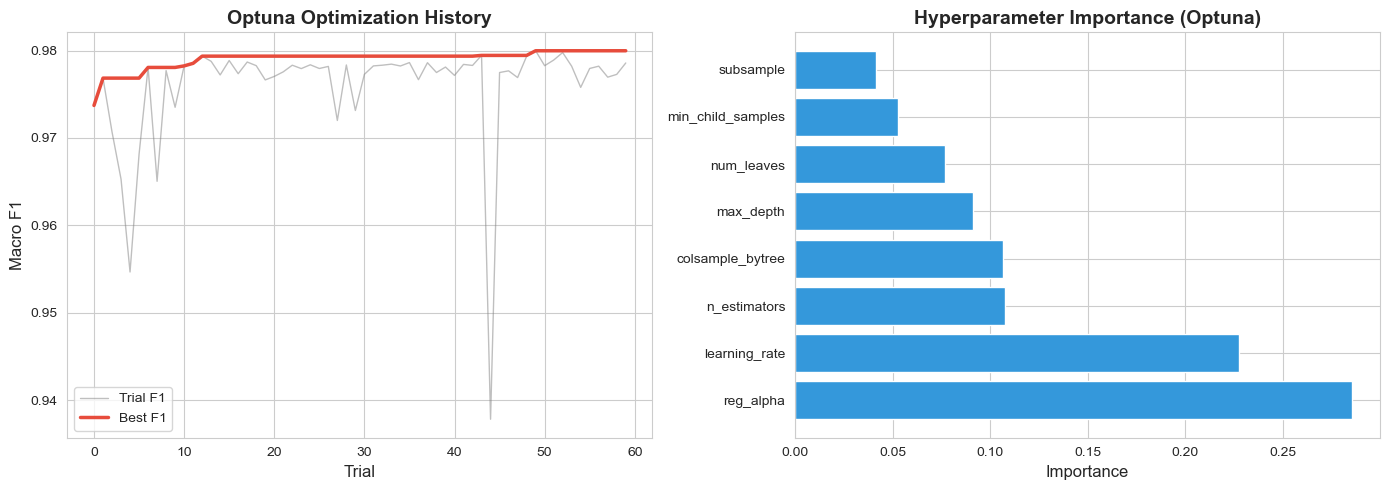

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

trial_values = [t.value for t in study.trials if t.value is not None]
axes[0].plot(trial_values, alpha=0.5, linewidth=1, color='gray', label='Trial F1')
running_best = pd.Series(trial_values).cummax()
axes[0].plot(running_best, color='#E74C3C', linewidth=2.5, label='Best F1')
axes[0].set_title('Optuna Optimization History', fontweight='bold')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Macro F1')
axes[0].legend()

try:
    param_imp = optuna.importance.get_param_importances(study)
    top_params = dict(list(param_imp.items())[:8])
    axes[1].barh(list(top_params.keys()), list(top_params.values()),
                 color='#3498DB', edgecolor='white')
    axes[1].set_title('Hyperparameter Importance (Optuna)', fontweight='bold')
    axes[1].set_xlabel('Importance')
except Exception:
    axes[1].text(0.5, 0.5, 'Param importance\ntidak tersedia', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title('Hyperparameter Importance', fontweight='bold')

plt.tight_layout()
plt.savefig('optuna_tuning.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
final_params = {**best_params, 'random_state': RANDOM_STATE, 'n_jobs': -1}

if best_model_name == 'LightGBM':
    final_params.update({'class_weight': 'balanced', 'verbose': -1})
    final_model = lgb.LGBMClassifier(**final_params)

elif best_model_name == 'XGBoost':
    final_params.update({'eval_metric': 'mlogloss', 'use_label_encoder': False})
    final_model = XGBClassifier(**final_params)

elif best_model_name == 'Extra Trees':
    final_params['class_weight'] = 'balanced'
    final_model = ExtraTreesClassifier(**final_params)

elif best_model_name == 'Random Forest':
    final_params['class_weight'] = 'balanced'
    final_model = RandomForestClassifier(**final_params)

elif best_model_name == 'Gradient Boosting':
    # GradientBoostingClassifier tidak support class_weight langsung
    final_params.pop('class_weight', None)
    final_model = GradientBoostingClassifier(**final_params)

else:
    final_params.update({'class_weight': 'balanced', 'verbose': -1})
    final_model = lgb.LGBMClassifier(**{k:v for k,v in final_params.items()
                                         if k in lgb.LGBMClassifier().get_params()})

final_model.fit(X_train_res, y_train_res)
y_pred_final  = final_model.predict(X_test_sel)
y_proba_final = final_model.predict_proba(X_test_sel)

acc_f    = accuracy_score(y_test_enc, y_pred_final)
bal_acc_f= balanced_accuracy_score(y_test_enc, y_pred_final)
f1_mac_f = f1_score(y_test_enc, y_pred_final, average='macro',    zero_division=0)
f1_wt_f  = f1_score(y_test_enc, y_pred_final, average='weighted', zero_division=0)

print("=" * 65)
print(f"FINAL EVALUATION — {best_model_name} (Setelah Optuna Tuning)")
print("=" * 65)
print(f"  Accuracy          : {acc_f:.4f}")
print(f"  Balanced Accuracy : {bal_acc_f:.4f}")
print(f"  Macro F1          : {f1_mac_f:.4f}")
print(f"  Weighted F1       : {f1_wt_f:.4f}")
print()
print("Classification Report:")
print(classification_report(
    y_test_enc, y_pred_final,
    target_names=['Normal', 'Ringan', 'Sedang', 'Tinggi'],
    zero_division=0
))

init_f1 = init_metrics[best_model_name]['F1 Macro']
print(f"  F1 Macro SEBELUM tuning: {init_f1:.4f}")
print(f"  F1 Macro SESUDAH tuning : {f1_mac_f:.4f}")
delta = f1_mac_f - init_f1
icon = '📈' if delta >= 0 else '📉'
print(f"  {icon} Perubahan             : {delta:+.4f}")

FINAL EVALUATION — LightGBM (Setelah Optuna Tuning)
  Accuracy          : 0.9777
  Balanced Accuracy : 0.8753
  Macro F1          : 0.9046
  Weighted F1       : 0.9774

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99      1310
      Ringan       0.96      0.97      0.97       652
      Sedang       0.86      0.55      0.67        11
      Tinggi       1.00      1.00      1.00         3

    accuracy                           0.98      1976
   macro avg       0.95      0.88      0.90      1976
weighted avg       0.98      0.98      0.98      1976

  F1 Macro SEBELUM tuning: 0.8757
  F1 Macro SESUDAH tuning : 0.9046
  📈 Perubahan             : +0.0289


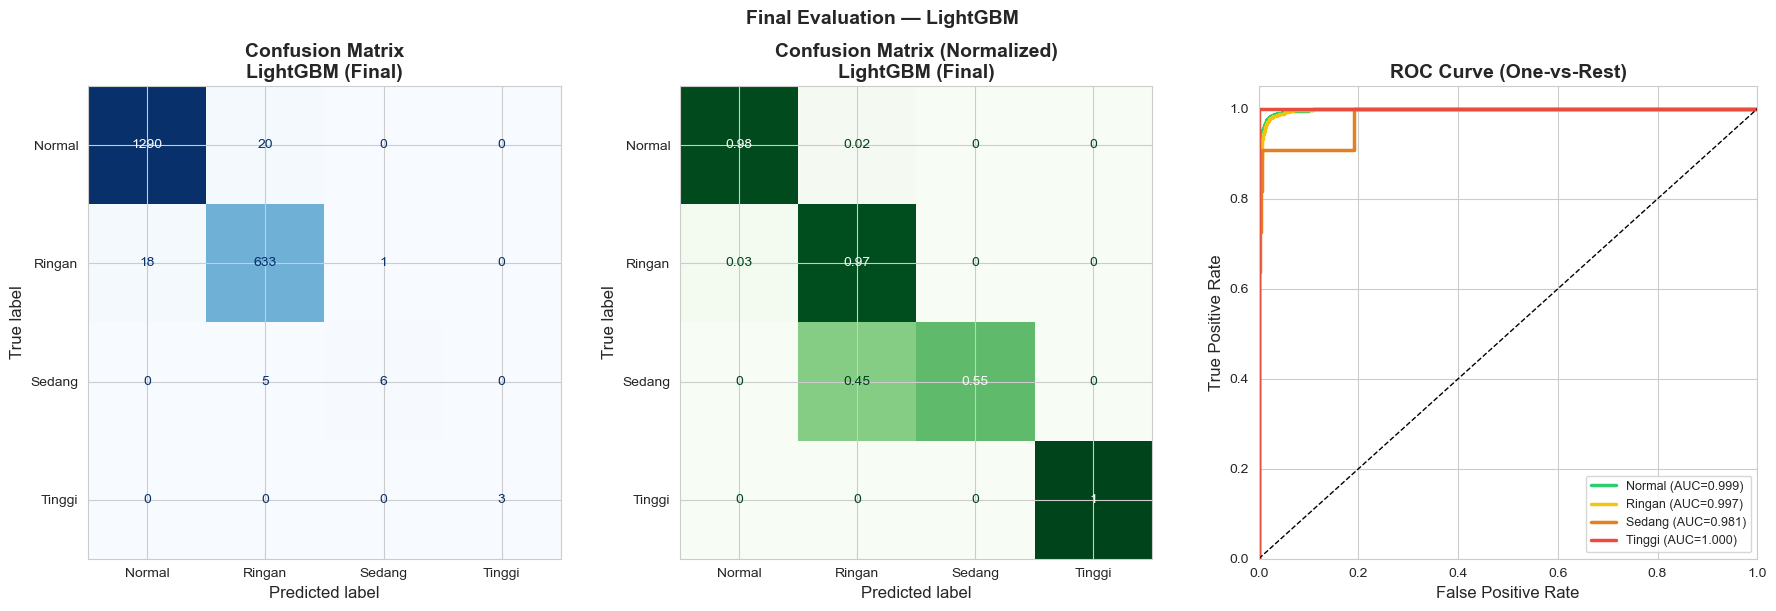

In [ ]:
fig = plt.figure(figsize=(18, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig)

ax1  = fig.add_subplot(gs[0])
cm_f = confusion_matrix(y_test_enc, y_pred_final)
disp = ConfusionMatrixDisplay(cm_f, display_labels=['Normal','Ringan','Sedang','Tinggi'])
disp.plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title(f'Confusion Matrix\n{best_model_name} (Final)', fontweight='bold')

ax2 = fig.add_subplot(gs[1])
cm_norm = cm_f.astype(float) / cm_f.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(np.round(cm_norm, 2), display_labels=['Normal','Ringan','Sedang','Tinggi'])
disp2.plot(ax=ax2, cmap='Greens', colorbar=False)
ax2.set_title(f'Confusion Matrix (Normalized)\n{best_model_name} (Final)', fontweight='bold')

ax3  = fig.add_subplot(gs[2])
y_bin = label_binarize(y_test_enc, classes=[0, 1, 2, 3])
for i, (cls_name, color) in enumerate(zip(['Normal','Ringan','Sedang','Tinggi'], CLASS_COLORS)):
    if y_bin[:, i].sum() > 0:
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba_final[:, i])
        roc_auc     = auc(fpr, tpr)
        ax3.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{cls_name} (AUC={roc_auc:.3f})')
ax3.plot([0,1],[0,1], 'k--', linewidth=1)
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curve (One-vs-Rest)', fontweight='bold')
ax3.legend(loc='lower right', fontsize=9)

plt.suptitle(f'Final Evaluation — {best_model_name}', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('final_evaluation.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
print("Per-Kelas Metrik Detail:")
print("-" * 60)
cls_report = classification_report(
    y_test_enc, y_pred_final,
    target_names=['Normal','Ringan','Sedang','Tinggi'],
    output_dict=True, zero_division=0
)
for cls in ['Normal','Ringan','Sedang','Tinggi']:
    r = cls_report[cls]
    print(f"  {cls:<30}: P={r['precision']:.3f} | R={r['recall']:.3f} | "
          f"F1={r['f1-score']:.3f} | Support={int(r['support'])}")

Per-Kelas Metrik Detail:
------------------------------------------------------------
  Normal                        : P=0.986 | R=0.985 | F1=0.985 | Support=1310
  Ringan                        : P=0.962 | R=0.971 | F1=0.966 | Support=652
  Sedang                        : P=0.857 | R=0.545 | F1=0.667 | Support=11
  Tinggi                        : P=1.000 | R=1.000 | F1=1.000 | Support=3


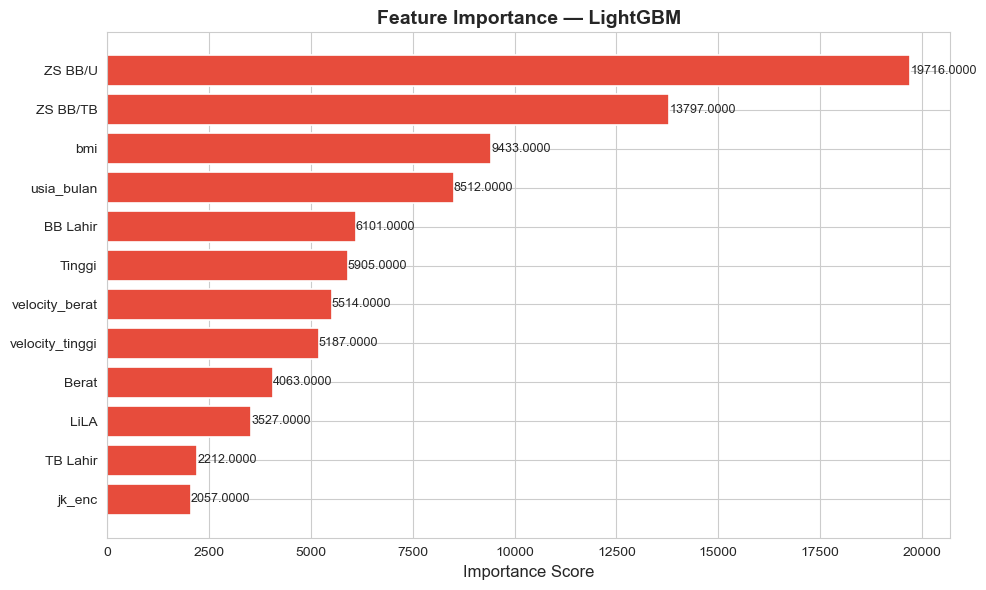

          Fitur  Importance
        ZS BB/U       19716
       ZS BB/TB       13797
            bmi        9433
     usia_bulan        8512
       BB Lahir        6101
         Tinggi        5905
 velocity_berat        5514
velocity_tinggi        5187
          Berat        4063
           LiLA        3527
       TB Lahir        2212
         jk_enc        2057


In [ ]:
if hasattr(final_model, 'feature_importances_'):
    fi = pd.DataFrame({
        'Fitur'      : [selected_feats[i] for i in range(len(selected_feats))],
        'Importance' : final_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(fi['Fitur'][::-1], fi['Importance'][::-1],
                   color='#E74C3C', edgecolor='white', linewidth=1.2)
    ax.set_title(f'Feature Importance — {best_model_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance Score')
    for bar, val in zip(bars, fi['Importance'][::-1]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(fi.to_string(index=False))
else:
    print("Model tidak memiliki built-in feature importance.")

Menghitung SHAP values (ini bisa memakan waktu 1-3 menit)...


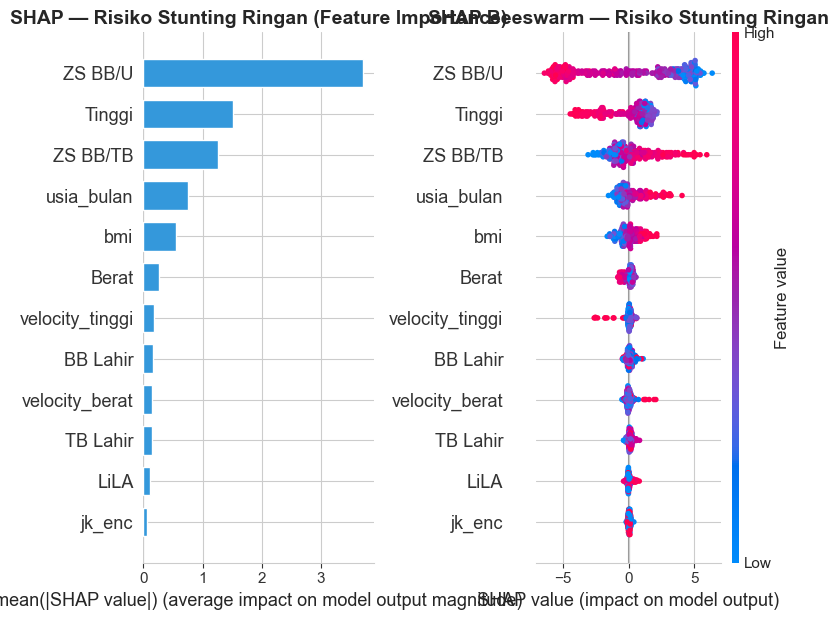


✅ SHAP berhasil dihitung!


In [ ]:
print("Menghitung SHAP values (ini bisa memakan waktu 1-3 menit)...")

N_SHAP = min(300, len(X_test_sel))
X_shap = X_test_sel[:N_SHAP]

try:
    if best_model_name in ('LightGBM', 'XGBoost'):
        explainer   = shap.TreeExplainer(final_model)
        shap_values = explainer.shap_values(X_shap)
    else:
        explainer   = shap.TreeExplainer(final_model)
        shap_values = explainer.shap_values(X_shap)

    shap_feat_names = selected_feats

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    plt.sca(axes[0])
    shap_vals_class1 = shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]
    shap.summary_plot(
        shap_vals_class1, X_shap, feature_names=shap_feat_names,
        plot_type='bar', show=False, color='#3498DB'
    )
    axes[0].set_title('SHAP — Risiko Stunting Ringan (Feature Importance)', fontweight='bold')

    plt.sca(axes[1])
    shap_vals_class1_dot = shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]
    shap.summary_plot(
        shap_vals_class1_dot, X_shap, feature_names=shap_feat_names,
        plot_type='dot', show=False
    )
    axes[1].set_title('SHAP Beeswarm — Risiko Stunting Ringan', fontweight='bold')

    plt.tight_layout()
    plt.savefig('shap_summary.png', bbox_inches='tight', dpi=150)
    plt.show()
    print("\n✅ SHAP berhasil dihitung!")
except Exception as e:
    print(f"SHAP dengan TreeExplainer gagal: {e}")
    print("Mencoba dengan KernelExplainer (lebih lambat)...")
    try:
        background  = shap.sample(X_shap, 50, random_state=RANDOM_STATE)
        explainer   = shap.KernelExplainer(final_model.predict_proba, background)
        shap_values = explainer.shap_values(X_shap[:50], nsamples=100)
        print("✅ KernelExplainer berhasil.")
    except Exception as e2:
        print(f"KernelExplainer juga gagal: {e2}")
        print("Lewati SHAP — gunakan built-in feature importance saja.")
        print("\n💡 Tip: Install shap>=0.42 untuk kompatibilitas penuh dengan LightGBM/XGBoost terbaru.")
        shap_values = None

In [ ]:
if shap_values is not None:
    try:
        shap_class_idx = 2
        class_indices  = np.where(y_test_enc == shap_class_idx)[0]

        if len(class_indices) > 0:
            idx = class_indices[0]
            if idx < N_SHAP:
                cls_name = CLASS_NAMES[shap_class_idx]
                print(f"\n📋 SHAP Force Plot — Contoh kasus: {cls_name}")
                print(f"   Prediksi model: {CLASS_NAMES[y_pred_final[idx]]}")
                print(f"   Label aktual  : {cls_name}")
                print(f"   Nilai fitur   :")
                for j, feat in enumerate(shap_feat_names):
                    print(f"     {feat:<25}: {X_test_sel[idx, j]:.3f}")
    except Exception as e:
        print(f"Force plot tidak tersedia: {e}")


📋 SHAP Force Plot — Contoh kasus: Risiko Stunting Sedang
   Prediksi model: Risiko Stunting Ringan
   Label aktual  : Risiko Stunting Sedang
   Nilai fitur   :
     ZS BB/U                  : -1.427
     Tinggi                   : 0.261
     Berat                    : 0.135
     bmi                      : -0.285
     BB Lahir                 : -0.297
     ZS BB/TB                 : -0.052
     LiLA                     : -0.379
     velocity_berat           : -0.216
     velocity_tinggi          : -3.628
     usia_bulan               : 0.738
     TB Lahir                 : 0.304
     jk_enc                   : 0.947


In [ ]:
import joblib
import json
import os

os.makedirs('model_artifacts', exist_ok=True)

joblib.dump(final_model, 'model_artifacts/stunting_model.pkl')
joblib.dump(scaler,      'model_artifacts/scaler.pkl')
joblib.dump(le_target,   'model_artifacts/label_encoder.pkl')

metadata = {
    'model_name'     : best_model_name,
    'feature_cols'   : selected_feats,
    'all_feature_cols': FEATURE_COLS,
    'class_names'    : CLASS_NAMES,
    'best_params'    : {k: str(v) for k, v in best_params.items()},
    'metrics': {
        'accuracy'         : round(acc_f, 4),
        'balanced_accuracy': round(bal_acc_f, 4),
        'f1_macro'         : round(f1_mac_f, 4),
        'f1_weighted'      : round(f1_wt_f, 4)
    },
    'mi_threshold'   : MI_THRESHOLD,
    'smote_target_n' : target_n,
    'random_state'   : RANDOM_STATE
}

with open('model_artifacts/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("=" * 55)
print("✅ MODEL BERHASIL DISIMPAN")
print("=" * 55)
print("File yang disimpan di 'model_artifacts/':")
for fn in os.listdir('model_artifacts'):
    size = os.path.getsize(f'model_artifacts/{fn}')
    print(f"  📁 {fn:<30} ({size:,} bytes)")
print(f"\nMetrics final model:")
for k, v in metadata['metrics'].items():
    print(f"  {k:<22}: {v}")

✅ MODEL BERHASIL DISIMPAN
File yang disimpan di 'model_artifacts/':
  📁 label_encoder.pkl              (679 bytes)
  📁 metadata.json                  (1,228 bytes)
  📁 scaler.pkl                     (951 bytes)
  📁 stunting_model.pkl             (10,046,084 bytes)

Metrics final model:
  accuracy              : 0.9777
  balanced_accuracy     : 0.8753
  f1_macro              : 0.9046
  f1_weighted           : 0.9774


In [ ]:
import joblib, json, numpy as np, pandas as pd, re

class StuntingDetector:
    """
    Sistem Deteksi Dini Stunting.

    Input  : Data antropometri balita (tanpa ZS TB/U)
    Output : Kelas risiko stunting + probabilitas tiap kelas
    """
    def __init__(self, model_dir='model_artifacts'):
        self.model    = joblib.load(f'{model_dir}/stunting_model.pkl')
        self.scaler   = joblib.load(f'{model_dir}/scaler.pkl')
        self.le       = joblib.load(f'{model_dir}/label_encoder.pkl')
        with open(f'{model_dir}/metadata.json') as f:
            self.meta = json.load(f)
        self.feature_cols  = self.meta['feature_cols']
        self.all_feats     = self.meta['all_feature_cols']
        self.class_names   = self.meta['class_names']
        print(f"✅ Model '{self.meta['model_name']}' berhasil dimuat")
        print(f"   Fitur yang digunakan: {len(self.feature_cols)}")
        print(f"   Kelas: {self.class_names}")

    @staticmethod
    def _parse_usia(usia_str):
        if pd.isna(usia_str): return np.nan
        m = re.match(r'(\d+)\s*Tahun\s*-\s*(\d+)\s*Bulan\s*-\s*(\d+)\s*Hari', str(usia_str))
        if not m: return np.nan
        t, b, h = map(int, m.groups())
        return t * 12 + b + h / 30.0

    def _build_features(self, data: dict) -> dict:
        """Membangun semua fitur dari input mentah."""
        if 'usia_bulan' not in data and 'Usia Saat Ukur' in data:
            data['usia_bulan'] = self._parse_usia(data['Usia Saat Ukur'])

        jk = str(data.get('JK', 'P')).strip().upper()
        data['jk_enc'] = 1 if jk == 'L' else 0

        naik_map = {'T': 2, 'N': 1}
        data['naik_bb_enc'] = naik_map.get(str(data.get('Naik Berat Badan', 'N')).strip(), 0)

        cara = str(data.get('Cara Ukur', 'Berdiri')).strip().lower()
        data['cara_ukur_enc'] = 1 if cara == 'berdiri' else 0

        berat  = float(data.get('Berat', 0))
        tinggi = float(data.get('Tinggi', 1))
        data['bmi'] = berat / ((tinggi / 100) ** 2) if tinggi > 0 else 0

        if 'ZS BB/U' in data:
            data['ZS BB/U'] = np.clip(float(data['ZS BB/U']), -5, 5)

        data.setdefault('velocity_berat',  0.0)
        data.setdefault('velocity_tinggi', 0.0)

        return data

    def predict(self, data: dict, verbose: bool = True) -> dict:
        """
        Prediksi risiko stunting untuk satu balita.

        Parameters
        ----------
        data : dict
            Kunci yang dibutuhkan: usia_bulan (atau Usia Saat Ukur), JK,
            BB Lahir, TB Lahir, Berat, Tinggi, LiLA,
            ZS BB/U, ZS BB/TB, Naik Berat Badan, Cara Ukur.
        verbose : bool
            Tampilkan output detail.

        Returns
        -------
        dict  dengan kunci: predicted_class, probability, risk_level
        """
        data = self._build_features(data.copy())

        full_feat_vals = []
        for feat in self.all_feats:
            col_map = {'BB Lahir': 'BB Lahir', 'TB Lahir': 'TB Lahir',
                       'Berat': 'Berat', 'Tinggi': 'Tinggi', 'LiLA': 'LiLA',
                       'ZS BB/U': 'ZS BB/U', 'ZS BB/TB': 'ZS BB/TB'}
            val = data.get(feat, data.get(col_map.get(feat, ''), 0))
            full_feat_vals.append(float(val) if val is not None else 0.0)

        X_full   = np.array(full_feat_vals).reshape(1, -1)
        X_scaled = self.scaler.transform(X_full)

        sel_idx  = [self.all_feats.index(f) for f in self.feature_cols if f in self.all_feats]
        X_sel    = X_scaled[:, sel_idx]

        pred_enc  = self.model.predict(X_sel)[0]
        pred_proba= self.model.predict_proba(X_sel)[0]
        pred_cls  = self.le.classes_[pred_enc]

        risk_icons = {
            'Normal'                : ('🟢', '✅ NORMAL'),
            'Risiko Stunting Ringan': ('🟡', '⚠️  RISIKO RINGAN — Pantau rutin'),
            'Risiko Stunting Sedang': ('🟠', '⚠️  RISIKO SEDANG — Intervensi segera'),
            'Risiko Stunting Tinggi': ('🔴', '🚨 RISIKO TINGGI — Perlu penanganan medis!')
        }

        if verbose:
            icon, status = risk_icons.get(pred_cls, ('❓', 'TIDAK DIKETAHUI'))
            print(f"\n{'='*55}")
            print(f"  {icon} HASIL PREDIKSI: {pred_cls}")
            print(f"  Status: {status}")
            print(f"{'='*55}")
            print(f"  Probabilitas per kelas:")
            for i, (cls, prob) in enumerate(zip(self.class_names, pred_proba)):
                bar = '█' * int(prob * 25)
                mark = ' ←' if i == pred_enc else ''
                print(f"    {cls:<32}: {prob:.3f}  {bar}{mark}")

        return {
            'predicted_class': pred_cls,
            'predicted_enc'  : int(pred_enc),
            'probability'    : pred_proba.tolist(),
            'risk_level'     : int(pred_enc)
        }

detector = StuntingDetector('model_artifacts')

✅ Model 'LightGBM' berhasil dimuat
   Fitur yang digunakan: 12
   Kelas: ['Normal', 'Risiko Stunting Ringan', 'Risiko Stunting Sedang', 'Risiko Stunting Tinggi']


In [ ]:
test_cases = [
    {
        'nama'              : 'Anak A — Perempuan 24 Bulan',
        'JK'                : 'P',
        'usia_bulan'        : 24.0,
        'BB Lahir'          : 3.2,
        'TB Lahir'          : 50.0,
        'Berat'             : 11.5,
        'Tinggi'            : 87.0,
        'LiLA'              : 14.5,
        'ZS BB/U'           : -0.30,
        'ZS BB/TB'          : 0.10,
        'Naik Berat Badan'  : 'T',
        'Cara Ukur'         : 'Berdiri',
        'label_asli'        : 'Normal',
    },
    {
        'nama'              : 'Anak B — Laki-Laki 18 Bulan',
        'JK'                : 'L',
        'usia_bulan'        : 18.0,
        'BB Lahir'          : 2.8,
        'TB Lahir'          : 48.0,
        'Berat'             : 9.0,
        'Tinggi'            : 77.0,
        'LiLA'              : 13.5,
        'ZS BB/U'           : -1.20,
        'ZS BB/TB'          : -0.50,
        'Naik Berat Badan'  : 'N',
        'Cara Ukur'         : 'Berdiri',
        'label_asli'        : 'Risiko Stunting Ringan',
    },
    {
        'nama'              : 'Anak C — Perempuan 36 Bulan',
        'JK'                : 'P',
        'usia_bulan'        : 36.0,
        'BB Lahir'          : 2.1,
        'TB Lahir'          : 46.0,
        'Berat'             : 10.5,
        'Tinggi'            : 88.0,
        'LiLA'              : 13.0,
        'ZS BB/U'           : -1.80,
        'ZS BB/TB'          : -1.20,
        'Naik Berat Badan'  : 'N',
        'Cara Ukur'         : 'Berdiri',
        'label_asli'        : 'Risiko Stunting Sedang',
    },
    {
        'nama'              : 'Anak D — Laki-Laki 30 Bulan',
        'JK'                : 'L',
        'usia_bulan'        : 30.0,
        'BB Lahir'          : 1.8,
        'TB Lahir'          : 44.0,
        'Berat'             : 9.0,
        'Tinggi'            : 82.0,
        'LiLA'              : 12.0,
        'ZS BB/U'           : -2.50,
        'ZS BB/TB'          : -1.80,
        'Naik Berat Badan'  : 'N',
        'Cara Ukur'         : 'Berdiri',
        'label_asli'        : 'Risiko Stunting Tinggi',
    },
]

print("=" * 60)
print("🧪 PENGUJIAN DATA BARU (UNSEEN DATA)")
print("=" * 60)

results = []
for case in test_cases:
    nama  = case.pop('nama')
    label = case.pop('label_asli')
    print(f"\n📋 {nama}")
    print(f"   Label Asli Referensi: {label}")
    result = detector.predict(case, verbose=True)
    match  = "✅ TEPAT" if result['predicted_class'] == label else "❌ TIDAK TEPAT"
    print(f"\n   Kesesuaian: {match}")
    results.append({
        'Nama'      : nama,
        'Label Asli': label,
        'Prediksi'  : result['predicted_class'],
        'Conf. Max' : f"{max(result['probability']):.3f}",
        'Status'    : match
    })

🧪 PENGUJIAN DATA BARU (UNSEEN DATA)

📋 Anak A — Perempuan 24 Bulan
   Label Asli Referensi: Normal

  🟢 HASIL PREDIKSI: Normal
  Status: ✅ NORMAL
  Probabilitas per kelas:
    Normal                          : 1.000  ████████████████████████ ←
    Risiko Stunting Ringan          : 0.000  
    Risiko Stunting Sedang          : 0.000  
    Risiko Stunting Tinggi          : 0.000  

   Kesesuaian: ✅ TEPAT

📋 Anak B — Laki-Laki 18 Bulan
   Label Asli Referensi: Risiko Stunting Ringan

  🟡 HASIL PREDIKSI: Risiko Stunting Ringan
  Status: ⚠️  RISIKO RINGAN — Pantau rutin
  Probabilitas per kelas:
    Normal                          : 0.000  
    Risiko Stunting Ringan          : 1.000  ████████████████████████ ←
    Risiko Stunting Sedang          : 0.000  
    Risiko Stunting Tinggi          : 0.000  

   Kesesuaian: ✅ TEPAT

📋 Anak C — Perempuan 36 Bulan
   Label Asli Referensi: Risiko Stunting Sedang

  🟡 HASIL PREDIKSI: Risiko Stunting Ringan
  Status: ⚠️  RISIKO RINGAN — Pantau rutin
  

In [ ]:
print("=" * 70)
print("📋 RANGKUMAN AKHIR PIPELINE")
print("=" * 70)
print(f"\n  Model Terpilih     : {best_model_name}")
print(f"  Fitur Digunakan    : {len(selected_feats)} dari {len(FEATURE_COLS)} fitur")
print(f"  Kelas Target       : {len(CLASS_NAMES)} kelas")
print(f"  Total Data         : {len(df_model):,} sampel")
print(f"  Training Set       : {len(X_train_res):,} (setelah SMOTE)")
print(f"  Test Set           : {len(X_test_sel):,}")
print()
print("  Metrics (Test Set):")
print(f"    Accuracy          : {acc_f:.4f}")
print(f"    Balanced Accuracy : {bal_acc_f:.4f}")
print(f"    Macro F1          : {f1_mac_f:.4f}")
print(f"    Weighted F1       : {f1_wt_f:.4f}")
print()
print("  Artefak Tersimpan di 'model_artifacts/':")
print("    📁 stunting_model.pkl  — Model terlatih")
print("    📁 scaler.pkl          — StandardScaler")
print("    📁 label_encoder.pkl   — Label Encoder target")
print("    📁 metadata.json       — Metadata & konfigurasi")
print()
print("  Penggunaan Model:")
print("    detector = StuntingDetector('model_artifacts')")
print("    result   = detector.predict({data_balita})")
print()
print("  Interpretasi Kelas:")
for i, cls in enumerate(CLASS_NAMES):
    icons = ['🟢','🟡','🟠','🔴']
    thresholds = ['ZS TB/U ≥ -1','−2 ≤ ZS < −1','−3 ≤ ZS < −2','ZS TB/U < −3']
    print(f"    {icons[i]} [{i}] {cls:<32}: {thresholds[i]}")
print()
print("✅ Pipeline selesai! Model siap digunakan untuk deteksi dini stunting.")

📋 RANGKUMAN AKHIR PIPELINE

  Model Terpilih     : LightGBM
  Fitur Digunakan    : 12 dari 14 fitur
  Kelas Target       : 4 kelas
  Total Data         : 9,878 sampel
  Training Set       : 8,894 (setelah SMOTE)
  Test Set           : 1,976

  Metrics (Test Set):
    Accuracy          : 0.9777
    Balanced Accuracy : 0.8753
    Macro F1          : 0.9046
    Weighted F1       : 0.9774

  Artefak Tersimpan di 'model_artifacts/':
    📁 stunting_model.pkl  — Model terlatih
    📁 scaler.pkl          — StandardScaler
    📁 label_encoder.pkl   — Label Encoder target
    📁 metadata.json       — Metadata & konfigurasi

  Penggunaan Model:
    detector = StuntingDetector('model_artifacts')
    result   = detector.predict({data_balita})

  Interpretasi Kelas:
    🟢 [0] Normal                          : ZS TB/U ≥ -1
    🟡 [1] Risiko Stunting Ringan          : −2 ≤ ZS < −1
    🟠 [2] Risiko Stunting Sedang          : −3 ≤ ZS < −2
    🔴 [3] Risiko Stunting Tinggi          : ZS TB/U < −3

✅ Pipeline 